# Chi-Squared Analysis: JEFF-4.0 vs JENDL-5 vs This Work

Consolidated per-experiment and per-energy chi-squared analysis with residual diagnostics.

**Definitions:**
- Combined uncertainty: $\sigma^{\mathrm{total}}_i = \sqrt{(\sigma^{\mathrm{exp}}_i)^2 + (\sigma^{\mathrm{eval}}_i)^2}$, where $\sigma^{\mathrm{eval}}$ is propagated from MF34 Legendre covariances
- Standardised residual: $r_i = (y^{\mathrm{exp}}_i - y^{\mathrm{eval}}_i)\,/\,\sigma^{\mathrm{total}}_i$
- Chi-squared per point: $\chi^2_i = r_i^2$
- Reduced chi-squared: $\chi^2/N = \sum_i \chi^2_i \,/\, N$

**Energy range:** 857 keV -- 4 MeV  
**Data source:** precomputed hybrid evaluations (`chi2_hybrid_data.parquet`)

In [1]:
# ── Imports & Configuration ───────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

PARQUET_PATH = '/share_snc/snc/JuanMonleon/chi2_hybrid_data.parquet'

E_MIN = 0.857   # MeV
E_MAX = 4.0     # MeV

LIBRARIES = ['JEFF', 'JENDL', 'This_work']
LIB_LABELS = {'JEFF': 'JEFF-4.0', 'JENDL': 'JENDL-5', 'This_work': 'This work'}
LIB_COLORS = {'JEFF': '#1f77b4', 'JENDL': '#2ca02c', 'This_work': '#d62728'}

N_ENERGY_BINS = 20

# -- Thesis-quality plot settings ---------------------------------------------
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 14,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'legend.fontsize': 12,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
})

# -- Figure export settings ---------------------------------------------------
SAVE_FIGURES = True
FIGURES_DIR = Path('/share_snc/snc/JuanMonleon/DA_Figures/chi2')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_FORMAT = 'png'
FIGURE_DPI = 300

def save_fig(fig, name):
    """Save figure if SAVE_FIGURES is True."""
    if SAVE_FIGURES:
        path = FIGURES_DIR / f'{name}.{FIGURE_FORMAT}'
        fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
        print(f'Saved: {path}')

In [2]:
# ── Load, filter, compute residuals ───────────────────────────────────────────

df_raw = pd.read_parquet(PARQUET_PATH)
print(f"Raw data: {len(df_raw)} rows")

# Energy filter
df = df_raw[(df_raw['energy_mev'] >= E_MIN) & (df_raw['energy_mev'] <= E_MAX)].copy()
print(f"After energy filter [{E_MIN}, {E_MAX}] MeV: {len(df)} rows")

# Drop rows with invalid uncertainties (fixes inf bug)
bad_mask = (df['sigma_exp'] <= 0) | ~np.isfinite(df['sigma_exp'])
n_bad = bad_mask.sum()
if n_bad > 0:
    print(f"Dropping {n_bad} rows with sigma_exp <= 0 or non-finite")
    df = df[~bad_mask].copy()

# Combine experimental and evaluated uncertainties
if 'sigma_eval' in df.columns:
    df['sigma_eval'] = df['sigma_eval'].fillna(0.0)
else:
    df['sigma_eval'] = 0.0
df['sigma_total'] = np.sqrt(df['sigma_exp']**2 + df['sigma_eval']**2)

# Compute residuals and chi2 using combined uncertainty
df['residual'] = (df['y_exp'] - df['y_eval']) / df['sigma_total']
df['chi2'] = df['residual'] ** 2

# No-MF34 baseline (exp-only uncertainty)
df['residual_noeval'] = (df['y_exp'] - df['y_eval']) / df['sigma_exp']
df['chi2_noeval'] = df['residual_noeval'] ** 2

# L=1-only MF34 diagnostic (guarded for backward compatibility)
HAS_L1_DIAGNOSTIC = 'sigma_eval_l1' in df.columns
if HAS_L1_DIAGNOSTIC:
    df['sigma_eval_l1'] = df['sigma_eval_l1'].fillna(0.0)
    df['sigma_total_l1'] = np.sqrt(df['sigma_exp']**2 + df['sigma_eval_l1']**2)
    df['residual_l1'] = (df['y_exp'] - df['y_eval']) / df['sigma_total_l1']
    df['chi2_l1'] = df['residual_l1'] ** 2
    print(f"L=1 diagnostic: enabled (sigma_eval_l1 column found)")
else:
    print(f"L=1 diagnostic: disabled (no sigma_eval_l1 column -- re-run precompute)")

# Drop non-finite chi2 values
inf_mask = ~np.isfinite(df['chi2'])
n_inf = inf_mask.sum()
if n_inf > 0:
    print(f"Dropping {n_inf} rows with non-finite chi2")
    df = df[~inf_mask].copy()

# Summary of sigma_eval contribution
has_eval = (df['sigma_eval'] > 0).sum()
print(f"\nMF34 sigma_eval: {has_eval}/{len(df)} rows have non-zero evaluated uncertainty")
if has_eval > 0:
    ratio = df.loc[df['sigma_eval'] > 0, 'sigma_eval'] / df.loc[df['sigma_eval'] > 0, 'sigma_exp']
    print(f"  sigma_eval/sigma_exp: median={ratio.median():.3f}, "
          f"mean={ratio.mean():.3f}, max={ratio.max():.3f}")

print(f"\nFinal dataset: {len(df)} rows")
print(f"Libraries: {df['library'].unique().tolist()}")
print(f"Experiments: {df['experiment_id'].nunique()}")
print(f"Energy grid points: {df['energy_mev'].nunique()}")
print(f"\nRows per library:")
print(df.groupby('library').size().to_string())

Raw data: 147943 rows
After energy filter [0.857, 4.0] MeV: 67272 rows
Dropping 231 rows with sigma_exp <= 0 or non-finite
L=1 diagnostic: enabled (sigma_eval_l1 column found)

MF34 sigma_eval: 67041/67041 rows have non-zero evaluated uncertainty
  sigma_eval/sigma_exp: median=1.133, mean=1.786, max=36.979

Final dataset: 67041 rows
Libraries: ['JEFF', 'JENDL', 'This_work']
Experiments: 67
Energy grid points: 1674

Rows per library:
library
JEFF         22360
JENDL        22321
This_work    22360


## 1. Global Summary

  Library     N  chi2_total  chi2/N
 JEFF-4.0 22360  127258.353   5.691
  JENDL-5 22321  116179.032   5.205
This work 22360   37701.861   1.686
Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/chi2_global_bar.png


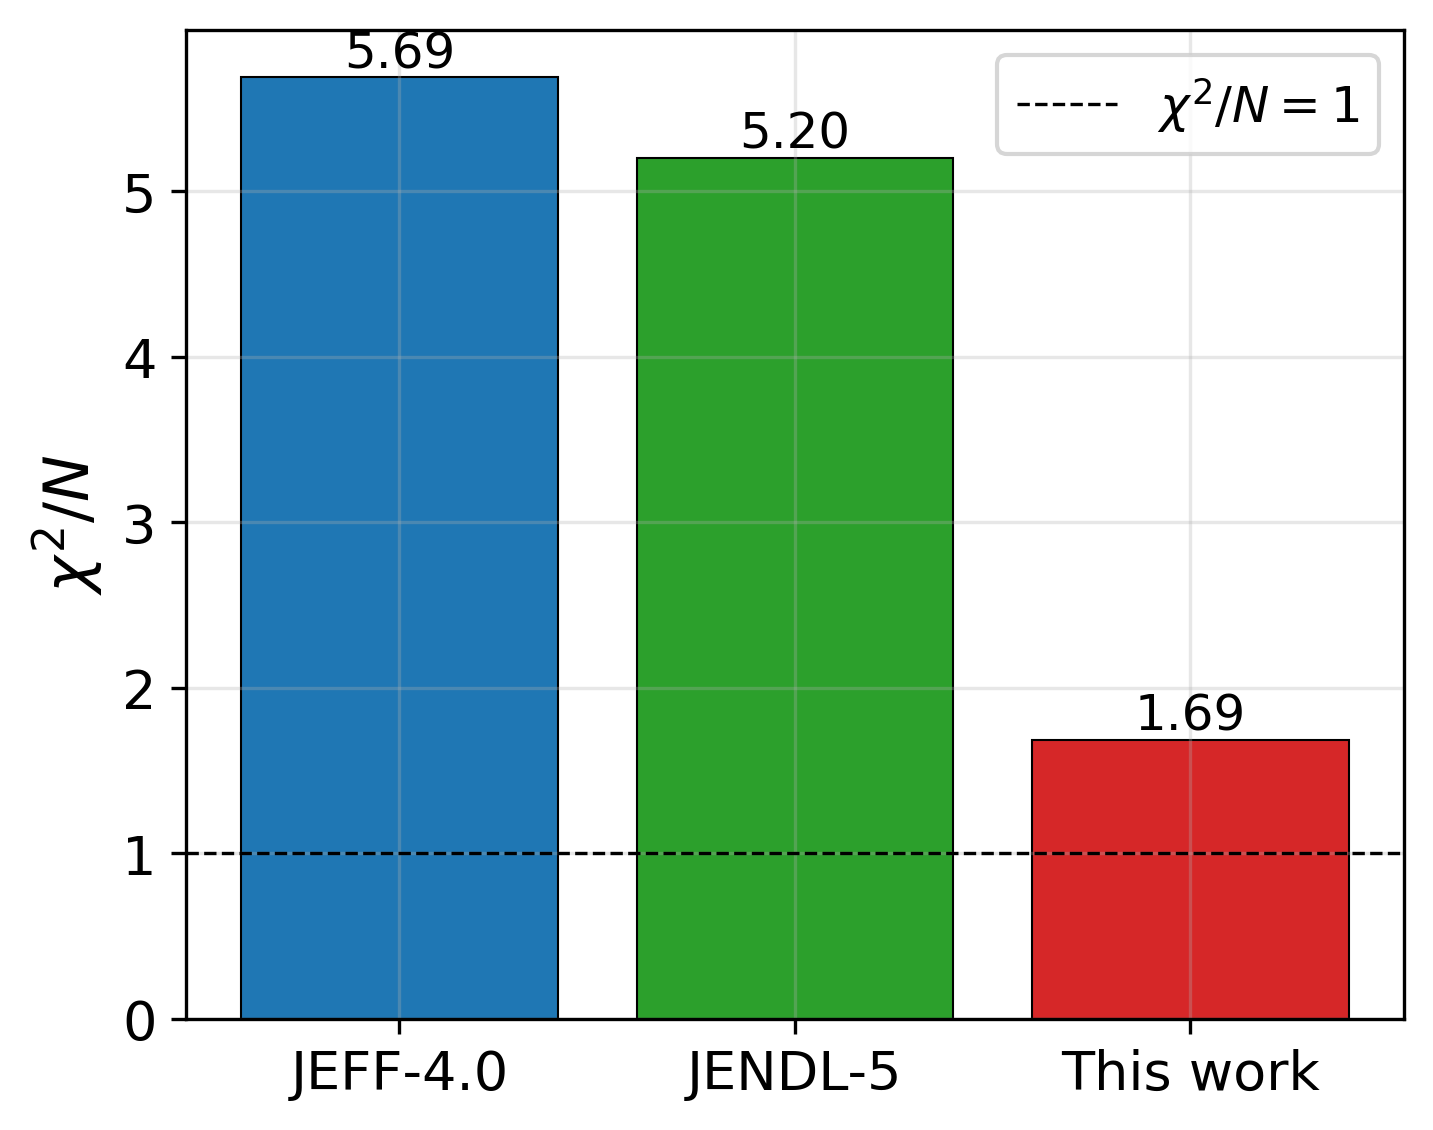

In [3]:
# ── Global chi2/N per library ─────────────────────────────────────────────────

summary = []
for lib in LIBRARIES:
    sub = df[df['library'] == lib]
    n = len(sub)
    chi2_total = sub['chi2'].sum()
    summary.append({
        'Library': LIB_LABELS[lib],
        'N': n,
        'chi2_total': chi2_total,
        'chi2/N': chi2_total / n if n > 0 else np.nan,
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False, float_format='%.3f'))

# Bar chart
fig, ax = plt.subplots(figsize=(5, 4))
labels = [LIB_LABELS[lib] for lib in LIBRARIES]
values = [summary_df.loc[summary_df['Library'] == LIB_LABELS[lib], 'chi2/N'].values[0]
          for lib in LIBRARIES]
colors = [LIB_COLORS[lib] for lib in LIBRARIES]

bars = ax.bar(labels, values, color=colors, edgecolor='k', linewidth=0.5)
ax.axhline(1.0, color='k', ls='--', lw=0.8, label=r'$\chi^2/N = 1$')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.2f}', ha='center', va='bottom', fontsize=12)

ax.set_ylabel(r'$\chi^2 / N$')
ax.legend()
fig.tight_layout()
save_fig(fig, 'chi2_global_bar')
plt.show()

### 1b. MF34 L=1 Diagnostic (JEFF only)

Tests whether higher Legendre orders (l > 1) have disproportionately large MF34 uncertainties
that inflate sigma_eval and artificially reduce chi2/N for JEFF.

Three scenarios compared:
1. **No MF34** -- exp-only uncertainty (baseline)
2. **MF34 l=1 only** -- only a1 variance propagated
3. **MF34 full** -- all Legendre orders propagated

Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/chi2_jeff_l1_diagnostic.png


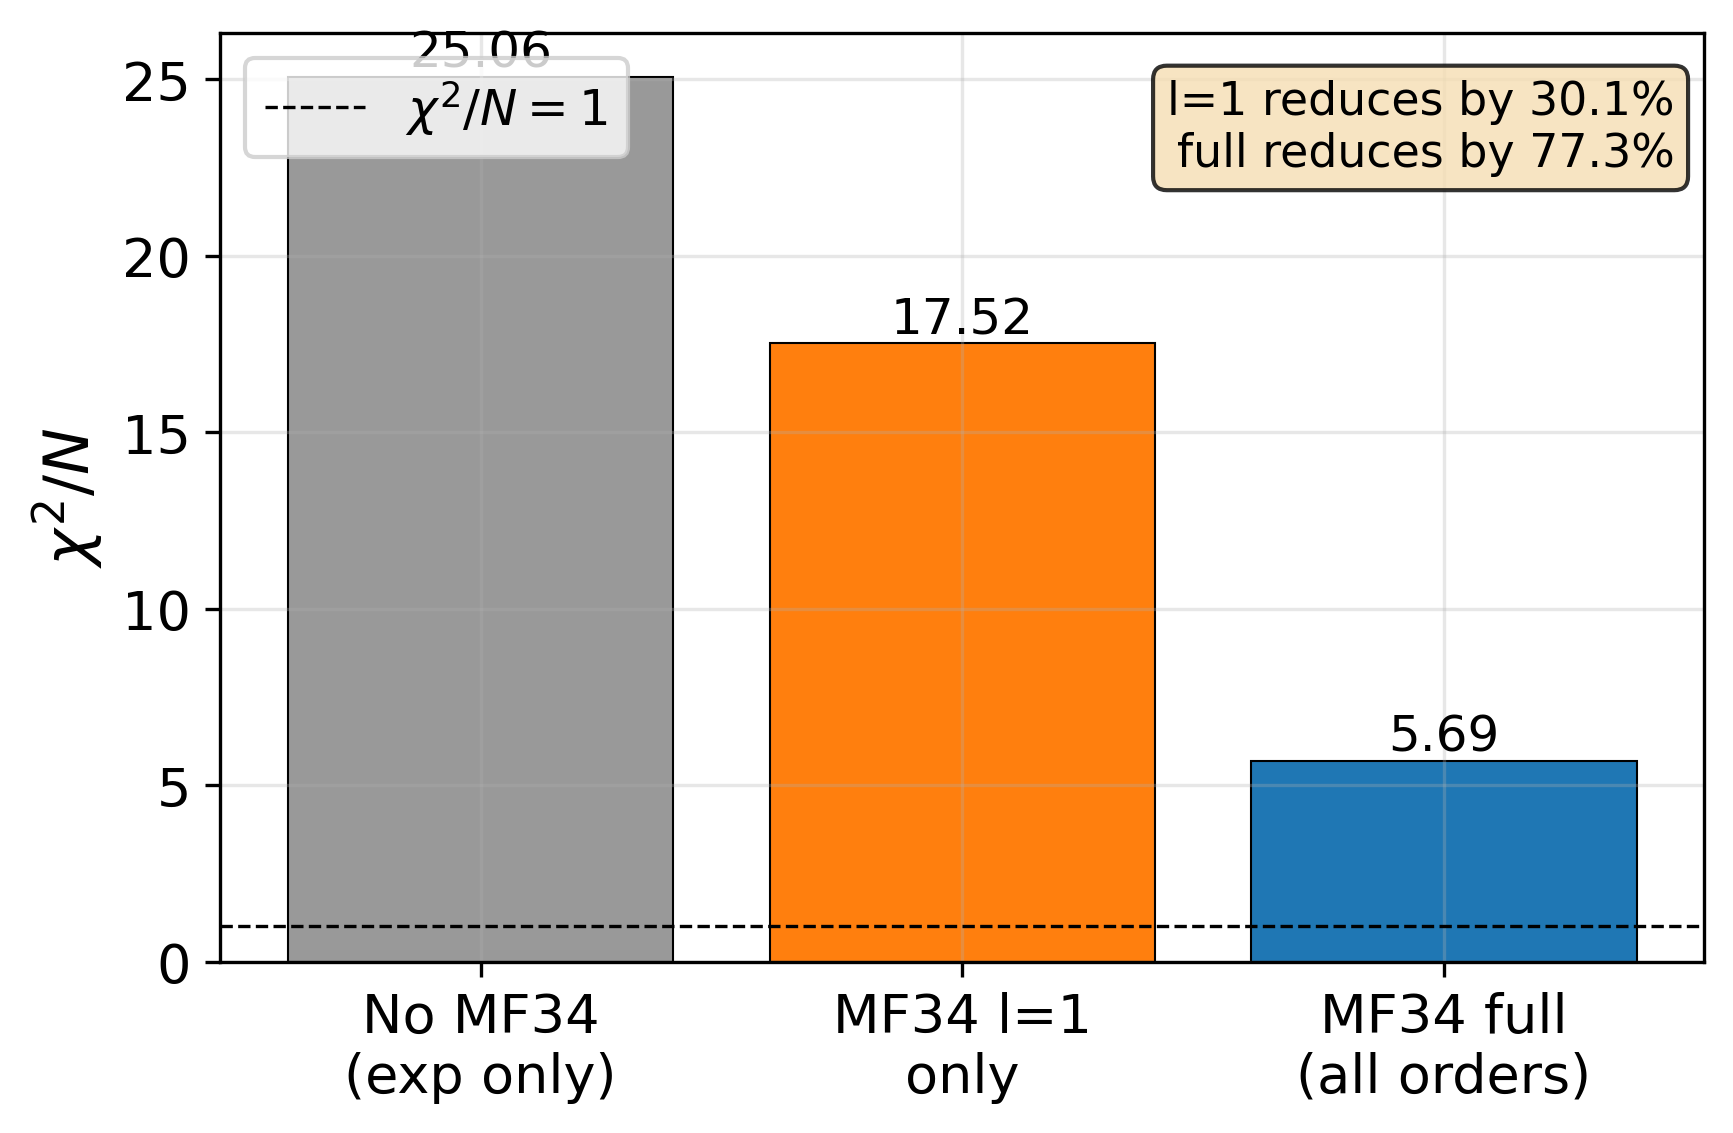

In [4]:
# ── L1 diagnostic: Global bar chart (JEFF) ───────────────────────────────────

if HAS_L1_DIAGNOSTIC:
    jeff = df[df['library'] == 'JEFF']
    n_jeff = len(jeff)

    chi2n_noeval = jeff['chi2_noeval'].sum() / n_jeff
    chi2n_l1     = jeff['chi2_l1'].sum() / n_jeff
    chi2n_full   = jeff['chi2'].sum() / n_jeff

    scenarios = ['No MF34\n(exp only)', 'MF34 l=1\nonly', 'MF34 full\n(all orders)']
    vals = [chi2n_noeval, chi2n_l1, chi2n_full]
    colors_bar = ['#999999', '#ff7f0e', '#1f77b4']

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(scenarios, vals, color=colors_bar, edgecolor='k', linewidth=0.5)
    ax.axhline(1.0, color='k', ls='--', lw=0.8, label=r'$\chi^2/N = 1$')

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=12)

    # Percentage reduction annotations
    if chi2n_noeval > 0:
        pct_l1   = 100.0 * (chi2n_noeval - chi2n_l1) / chi2n_noeval
        pct_full = 100.0 * (chi2n_noeval - chi2n_full) / chi2n_noeval
        ax.text(0.98, 0.95,
                f'l=1 reduces by {pct_l1:.1f}%\nfull reduces by {pct_full:.1f}%',
                transform=ax.transAxes, ha='right', va='top', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.8))

    ax.set_ylabel(r'$\chi^2 / N$')
    ax.legend(loc='upper left')
    fig.tight_layout()
    save_fig(fig, 'chi2_jeff_l1_diagnostic')
    plt.show()
else:
    print("Skipped: L1 diagnostic not available (re-run precompute notebook)")

Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/chi2_jeff_l1_vs_energy.png


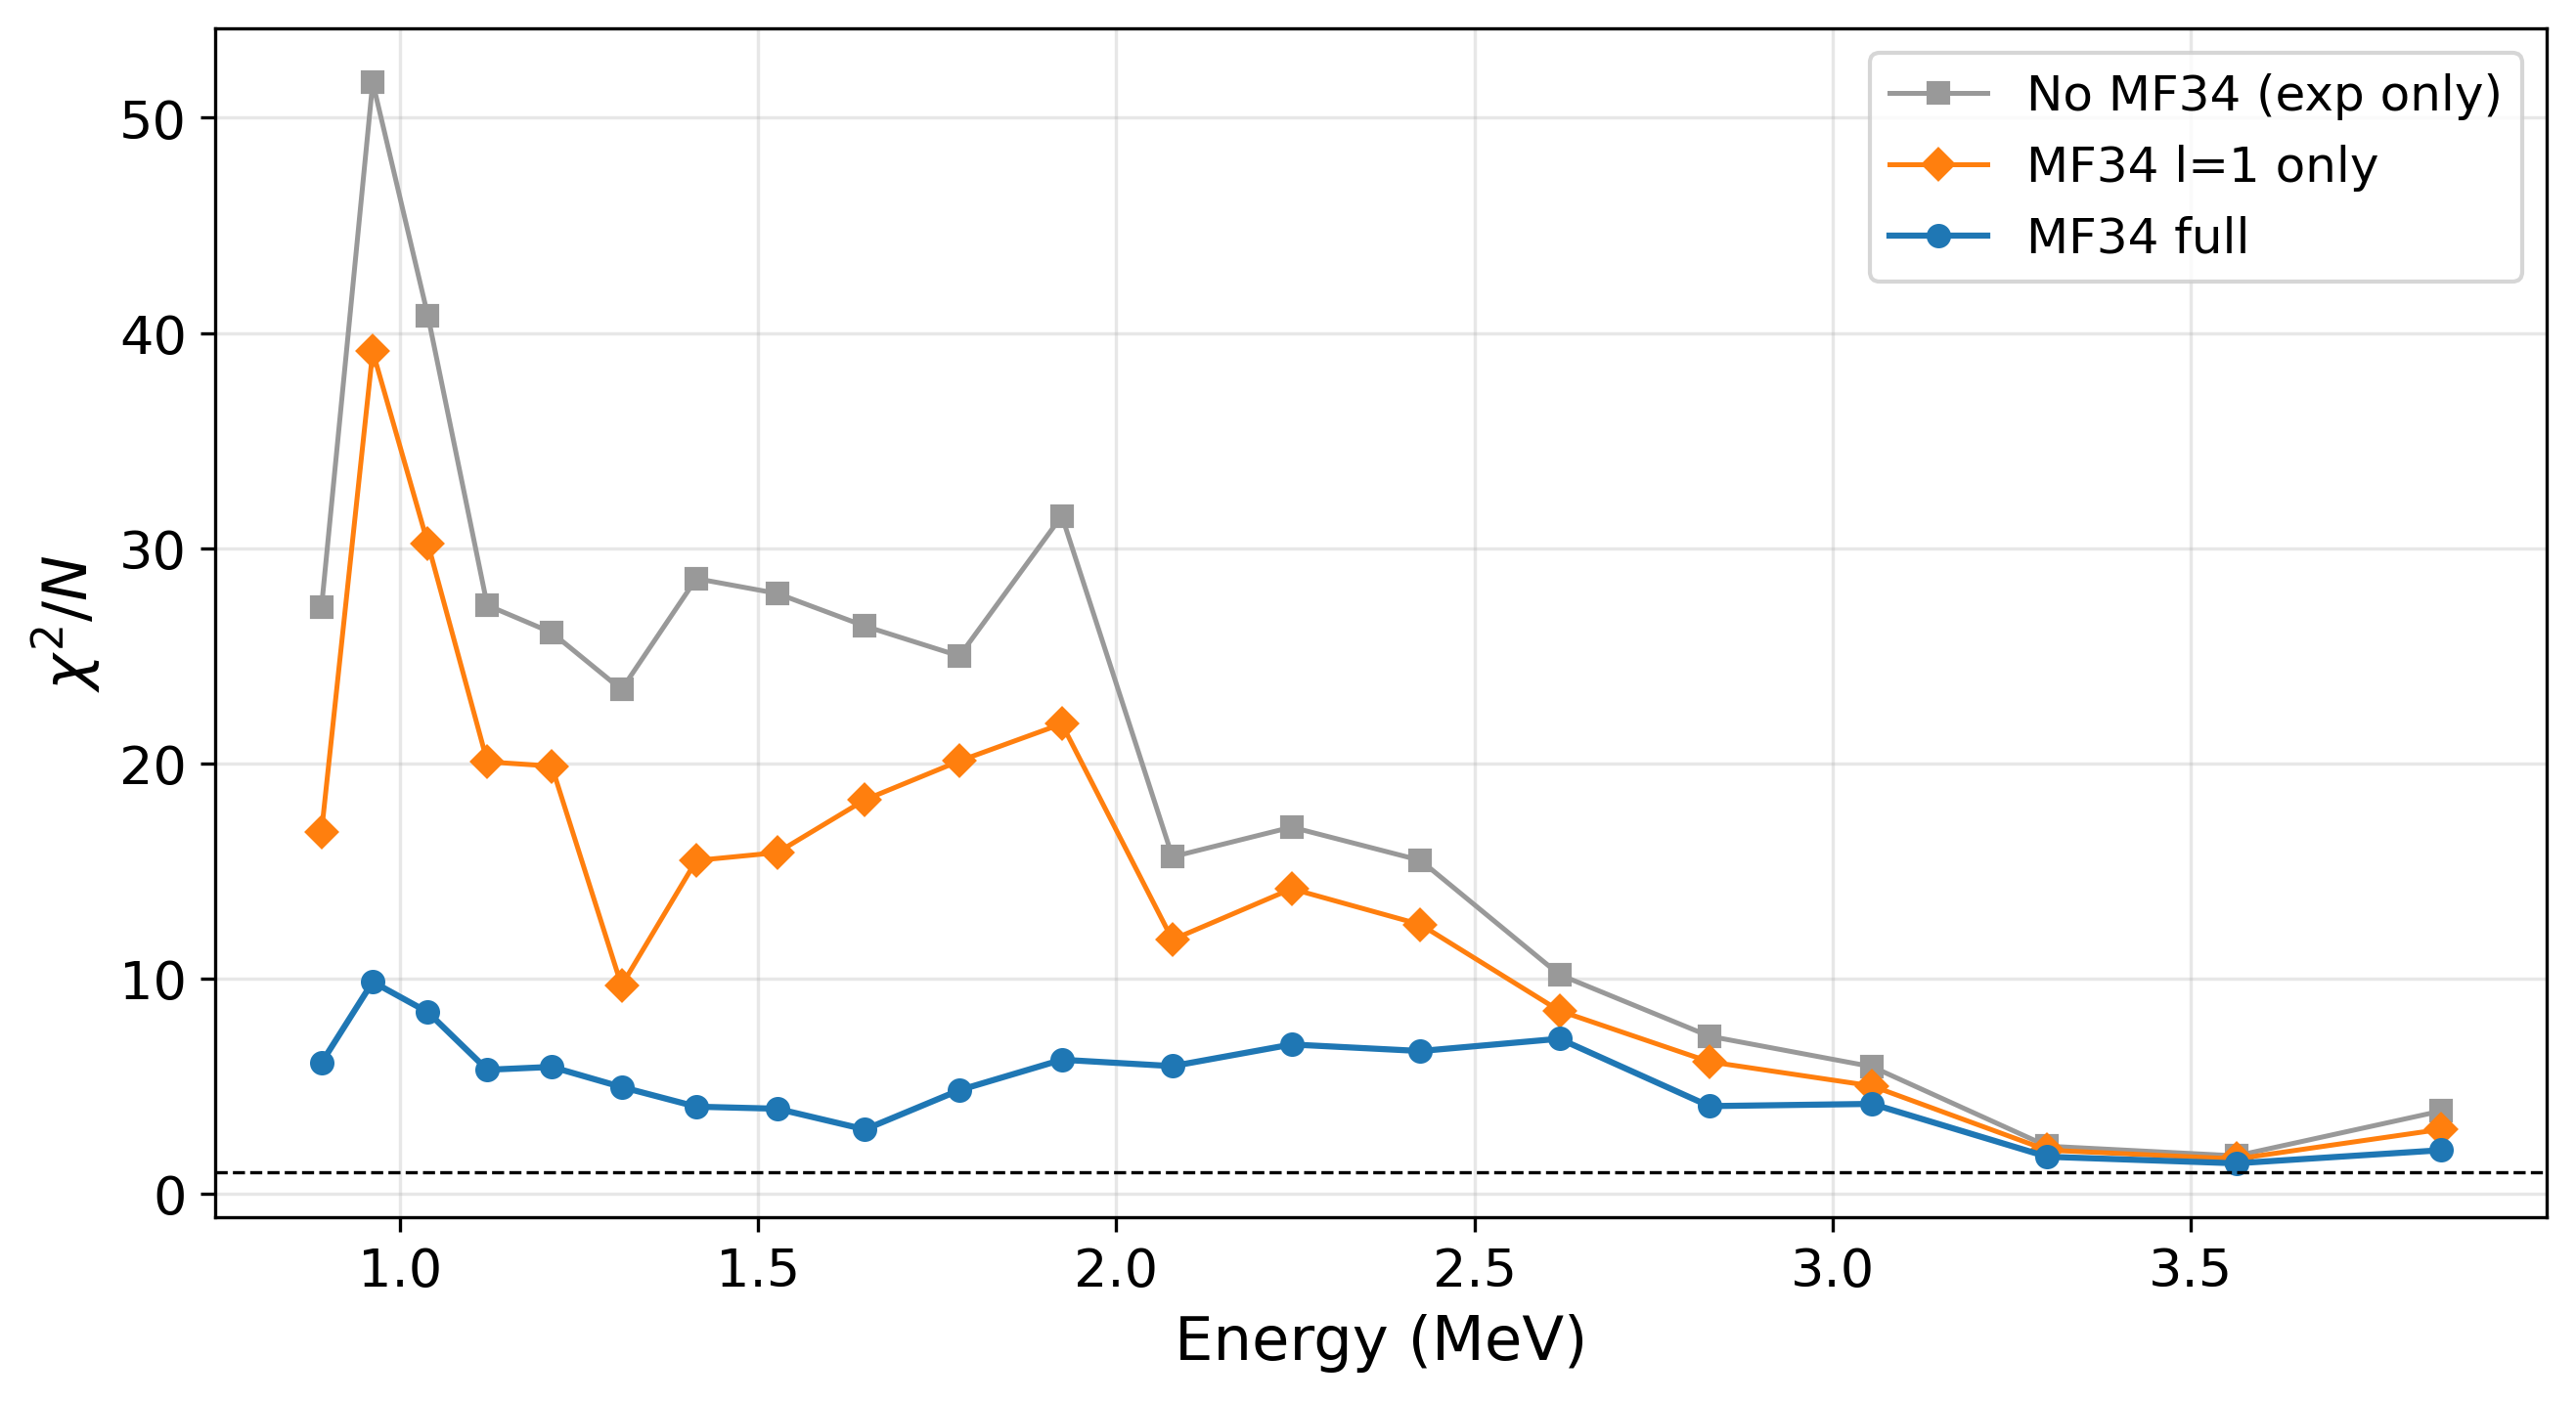

In [5]:
# ── L1 diagnostic: Per-energy chi2/N (JEFF) ──────────────────────────────────────────

if HAS_L1_DIAGNOSTIC:
    jeff = df[df['library'] == 'JEFF'].copy()
    bin_edges_l1 = np.logspace(np.log10(E_MIN), np.log10(E_MAX), N_ENERGY_BINS + 1)
    jeff['e_bin_l1'] = pd.cut(jeff['energy_mev'], bins=bin_edges_l1)
    jeff['e_mid_l1'] = jeff['e_bin_l1'].apply(
        lambda x: np.sqrt(x.left * x.right) if pd.notna(x) else np.nan
    )

    grouped = jeff.groupby('e_bin_l1', observed=True)
    midpoints = grouped['e_mid_l1'].first().values
    n_per_bin = grouped['chi2'].count().values

    chi2n_noeval_e = grouped['chi2_noeval'].sum().values / n_per_bin
    chi2n_l1_e     = grouped['chi2_l1'].sum().values / n_per_bin
    chi2n_full_e   = grouped['chi2'].sum().values / n_per_bin

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(midpoints, chi2n_noeval_e, 's-', color='#999999', label='No MF34 (exp only)',
            markersize=5, linewidth=1.2)
    ax.plot(midpoints, chi2n_l1_e, 'D-', color='#ff7f0e', label='MF34 l=1 only',
            markersize=5, linewidth=1.2)
    ax.plot(midpoints, chi2n_full_e, 'o-', color='#1f77b4', label='MF34 full',
            markersize=5, linewidth=1.5)
    ax.axhline(1.0, color='k', ls='--', lw=0.8)

    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel(r'$\chi^2 / N$')
    ax.legend()
    fig.tight_layout()
    save_fig(fig, 'chi2_jeff_l1_vs_energy')
    plt.show()

    jeff.drop(columns=['e_bin_l1', 'e_mid_l1'], inplace=True, errors='ignore')

In [6]:
# ── L1 diagnostic: Per-experiment table (JEFF) ─────────────────────────────────────

if HAS_L1_DIAGNOSTIC:
    jeff = df[df['library'] == 'JEFF']

    exp_l1_stats = []
    for exp_id, grp in jeff.groupby('experiment_id', observed=True):
        n = len(grp)
        row0 = grp.iloc[0]
        exp_l1_stats.append({
            'experiment_id': exp_id,
            'author': row0['author'],
            'year': int(row0['year']) if pd.notna(row0['year']) else '',
            'N': n,
            'chi2/N_noeval': grp['chi2_noeval'].sum() / n,
            'chi2/N_l1':     grp['chi2_l1'].sum() / n,
            'chi2/N_full':   grp['chi2'].sum() / n,
        })

    exp_l1_df = pd.DataFrame(exp_l1_stats)
    exp_l1_df['delta_l1']   = exp_l1_df['chi2/N_noeval'] - exp_l1_df['chi2/N_l1']
    exp_l1_df['delta_full'] = exp_l1_df['chi2/N_noeval'] - exp_l1_df['chi2/N_full']
    exp_l1_df['delta_higher'] = exp_l1_df['delta_full'] - exp_l1_df['delta_l1']
    exp_l1_df = exp_l1_df.sort_values('delta_higher', ascending=False)

    print('JEFF-4.0: Per-experiment chi2/N under three MF34 scenarios')
    print('Sorted by delta_higher = reduction from l>1 orders (full - l1)\n')
    with pd.option_context('display.max_rows', 40, 'display.float_format', '{:.2f}'.format):
        print(exp_l1_df[['author', 'year', 'N',
                         'chi2/N_noeval', 'chi2/N_l1', 'chi2/N_full',
                         'delta_l1', 'delta_higher']].to_string(index=False))

JEFF-4.0: Per-experiment chi2/N under three MF34 scenarios
Sorted by delta_higher = reduction from l>1 orders (full - l1)

    author  year     N  chi2/N_noeval  chi2/N_l1  chi2/N_full  delta_l1  delta_higher
    Tomita  1973    13         284.22     241.72        30.62     42.50        211.09
    Vanhoy  2018    12         223.71     205.63         8.29     18.08        197.34
      Cabe  1967    11         856.59     365.65       177.77    490.94        187.88
    Tomita  1973    13         216.77     192.67        12.53     24.10        180.14
    Darden  1955     6         208.72     181.83        14.43     26.89        167.40
    Tomita  1973    13         186.07     171.71        15.47     14.36        156.25
    Tomita  1973    13         166.22     165.43        14.02      0.79        151.40
    Tomita  1973    13         380.76     171.83        21.58    208.94        150.25
    Tomita  1973    14         549.59     208.69        72.73    340.90        135.96
    Tomita  1973 

### 1c. JEFF vs JENDL: Why JEFF l=1 chi2/N < JENDL despite smaller l=1 uncertainties

Decomposes chi2/N into numerator (evaluation quality) and denominator (uncertainty size) to confirm
that JEFF's lower chi2 is driven by better MF4 central values, not larger uncertainties.

In [7]:
# ── JEFF vs JENDL: Numerator/denominator decomposition ───────────────────────
# chi2/N = mean(numerator / denominator) where:
#   numerator = (y_exp - y_eval)^2
#   denominator = sigma_total^2 (or sigma_total_l1^2 for l=1 scenario)
# A library can have lower chi2 either because its central values are closer
# to experiment (smaller numerator) OR because its uncertainties are larger
# (bigger denominator).

print("=" * 75)
print("JEFF vs JENDL: chi2/N decomposition (numerator vs denominator)")
print("=" * 75)

# Global JEFF diagnostic values (for LaTeX inline numbers)
if HAS_L1_DIAGNOSTIC:
    jeff = df[df['library'] == 'JEFF']
    n_jeff = len(jeff)
    print(f"\nJEFF-4.0 global chi2/N under three MF34 scenarios:")
    print(f"  No MF34 (exp only):  chi2/N = {jeff['chi2_noeval'].sum()/n_jeff:.2f}")
    print(f"  MF34 l=1 only:       chi2/N = {jeff['chi2_l1'].sum()/n_jeff:.2f}")
    print(f"  MF34 full:           chi2/N = {jeff['chi2'].sum()/n_jeff:.2f}")

print("\n--- Using l=1-only uncertainties for fair comparison ---\n")

for lib in ['JEFF', 'JENDL']:
    sub = df[df['library'] == lib]
    n = len(sub)

    numerator = (sub['y_exp'] - sub['y_eval']) ** 2
    mean_num = numerator.mean()

    if HAS_L1_DIAGNOSTIC:
        denom_l1 = sub['sigma_total_l1'] ** 2
        mean_den_l1 = denom_l1.mean()
        chi2n_l1 = (numerator / denom_l1).mean()
    else:
        denom = sub['sigma_total'] ** 2
        mean_den = denom.mean()

    denom_exp = sub['sigma_exp'] ** 2
    mean_den_exp = denom_exp.mean()

    print(f"{LIB_LABELS[lib]}:")
    print(f"  Mean squared residual numerator:  {mean_num:.6f}")
    print(f"  Mean sigma_exp^2 (denominator):   {mean_den_exp:.6f}")
    if HAS_L1_DIAGNOSTIC:
        print(f"  Mean sigma_total_l1^2 (denom):    {mean_den_l1:.6f}")
        print(f"  chi2/N (l=1 scenario):            {chi2n_l1:.3f}")
    print()

if HAS_L1_DIAGNOSTIC:
    jeff_sub = df[df['library'] == 'JEFF']
    jendl_sub = df[df['library'] == 'JENDL']

    jeff_num = ((jeff_sub['y_exp'] - jeff_sub['y_eval'])**2).mean()
    jendl_num = ((jendl_sub['y_exp'] - jendl_sub['y_eval'])**2).mean()
    jeff_den = (jeff_sub['sigma_total_l1']**2).mean()
    jendl_den = (jendl_sub['sigma_total_l1']**2).mean()

    print("--- Ratio comparison (JENDL / JEFF) ---")
    print(f"  Numerator ratio  (JENDL/JEFF): {jendl_num/jeff_num:.2f}x  "
          f"(>1 means JENDL has larger residuals)")
    print(f"  Denominator ratio (JENDL/JEFF): {jendl_den/jeff_den:.2f}x  "
          f"(<1 means JENDL has smaller uncertainties)")
    print(f"\n  -> Both factors work against JENDL: its central values are")
    print(f"     {jendl_num/jeff_num:.0%} worse AND its l=1 uncertainties are")
    print(f"     {1 - jendl_den/jeff_den:.0%} smaller than JEFF's.")

print("\n" + "=" * 75)

JEFF vs JENDL: chi2/N decomposition (numerator vs denominator)

JEFF-4.0 global chi2/N under three MF34 scenarios:
  No MF34 (exp only):  chi2/N = 25.06
  MF34 l=1 only:       chi2/N = 17.52
  MF34 full:           chi2/N = 5.69

--- Using l=1-only uncertainties for fair comparison ---

JEFF-4.0:
  Mean squared residual numerator:  0.003037
  Mean sigma_exp^2 (denominator):   0.001063
  Mean sigma_total_l1^2 (denom):    0.001098
  chi2/N (l=1 scenario):            17.518

JENDL-5:
  Mean squared residual numerator:  0.003357
  Mean sigma_exp^2 (denominator):   0.001058
  Mean sigma_total_l1^2 (denom):    0.001880
  chi2/N (l=1 scenario):            5.205

--- Ratio comparison (JENDL / JEFF) ---
  Numerator ratio  (JENDL/JEFF): 1.11x  (>1 means JENDL has larger residuals)
  Denominator ratio (JENDL/JEFF): 1.71x  (<1 means JENDL has smaller uncertainties)

  -> Both factors work against JENDL: its central values are
     111% worse AND its l=1 uncertainties are
     -71% smaller than JEFF

## 2. Per-Experiment Breakdown

In [8]:
# ── Per-experiment chi2/N pivot table ─────────────────────────────────────────

exp_stats = []
for (exp_id, lib), grp in df.groupby(['experiment_id', 'library'], observed=True):
    n = len(grp)
    chi2_total = grp['chi2'].sum()
    row = grp.iloc[0]
    exp_stats.append({
        'experiment_id': exp_id,
        'author': row['author'],
        'year': int(row['year']) if pd.notna(row['year']) else '',
        'E_min': grp['energy_mev'].min(),
        'E_max': grp['energy_mev'].max(),
        'library': lib,
        'N': n,
        'chi2_total': chi2_total,
        'chi2/N': chi2_total / n if n > 0 else np.nan,
    })

exp_df = pd.DataFrame(exp_stats)

# Pivot: experiments as rows, libraries as columns
pivot = exp_df.pivot_table(
    index=['experiment_id', 'author', 'year', 'E_min', 'E_max'],
    columns='library',
    values='chi2/N',
)
# Average across libraries for sorting
pivot['avg'] = pivot[LIBRARIES].mean(axis=1)
pivot = pivot.sort_values('avg', ascending=False)

# Add N from any library (same N per experiment)
n_per_exp = exp_df.groupby('experiment_id')['N'].first()
pivot = pivot.join(n_per_exp, on='experiment_id')

print(f"Per-experiment chi2/N (sorted by avg chi2/N descending):\n")
with pd.option_context('display.max_rows', 50, 'display.float_format', '{:.2f}'.format):
    display_cols = [c for c in pivot.columns if c != 'avg']
    print(pivot[display_cols].fillna('--').to_string())

Per-experiment chi2/N (sorted by avg chi2/N descending):

                                            JEFF  JENDL This_work      N
experiment_id author     year E_min E_max                               
20482005      Cabe       1967 0.97  0.97  177.77  19.69      4.23     11
11638003      Darden     1955 1.00  1.55   14.43 112.60      1.08      6
20008015      Tomita     1973 2.04  2.04   70.22  36.49      0.55     13
20008011      Tomita     1973 1.87  1.87   30.62  58.74      1.90     13
11276009      Rodgers    1967 2.33  2.33   59.41  29.08      0.68      5
20008013      Tomita     1973 1.94  1.94   72.73   9.71      0.29     14
20008002      Tomita     1973 1.43  1.43   14.02  57.98      2.77     13
11396011      Cranberg   1956 2.25  2.45   41.60  24.85      0.95      7
14451003      Vanhoy     2018 1.75  1.75    8.29  51.14      2.67     12
30076004      Barnard    1968 0.94  1.18   15.63  35.39      6.04    239
20008014      Tomita     1973 1.98  1.98    6.07  47.39      2.80 

Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/chi2_per_experiment_histogram.png


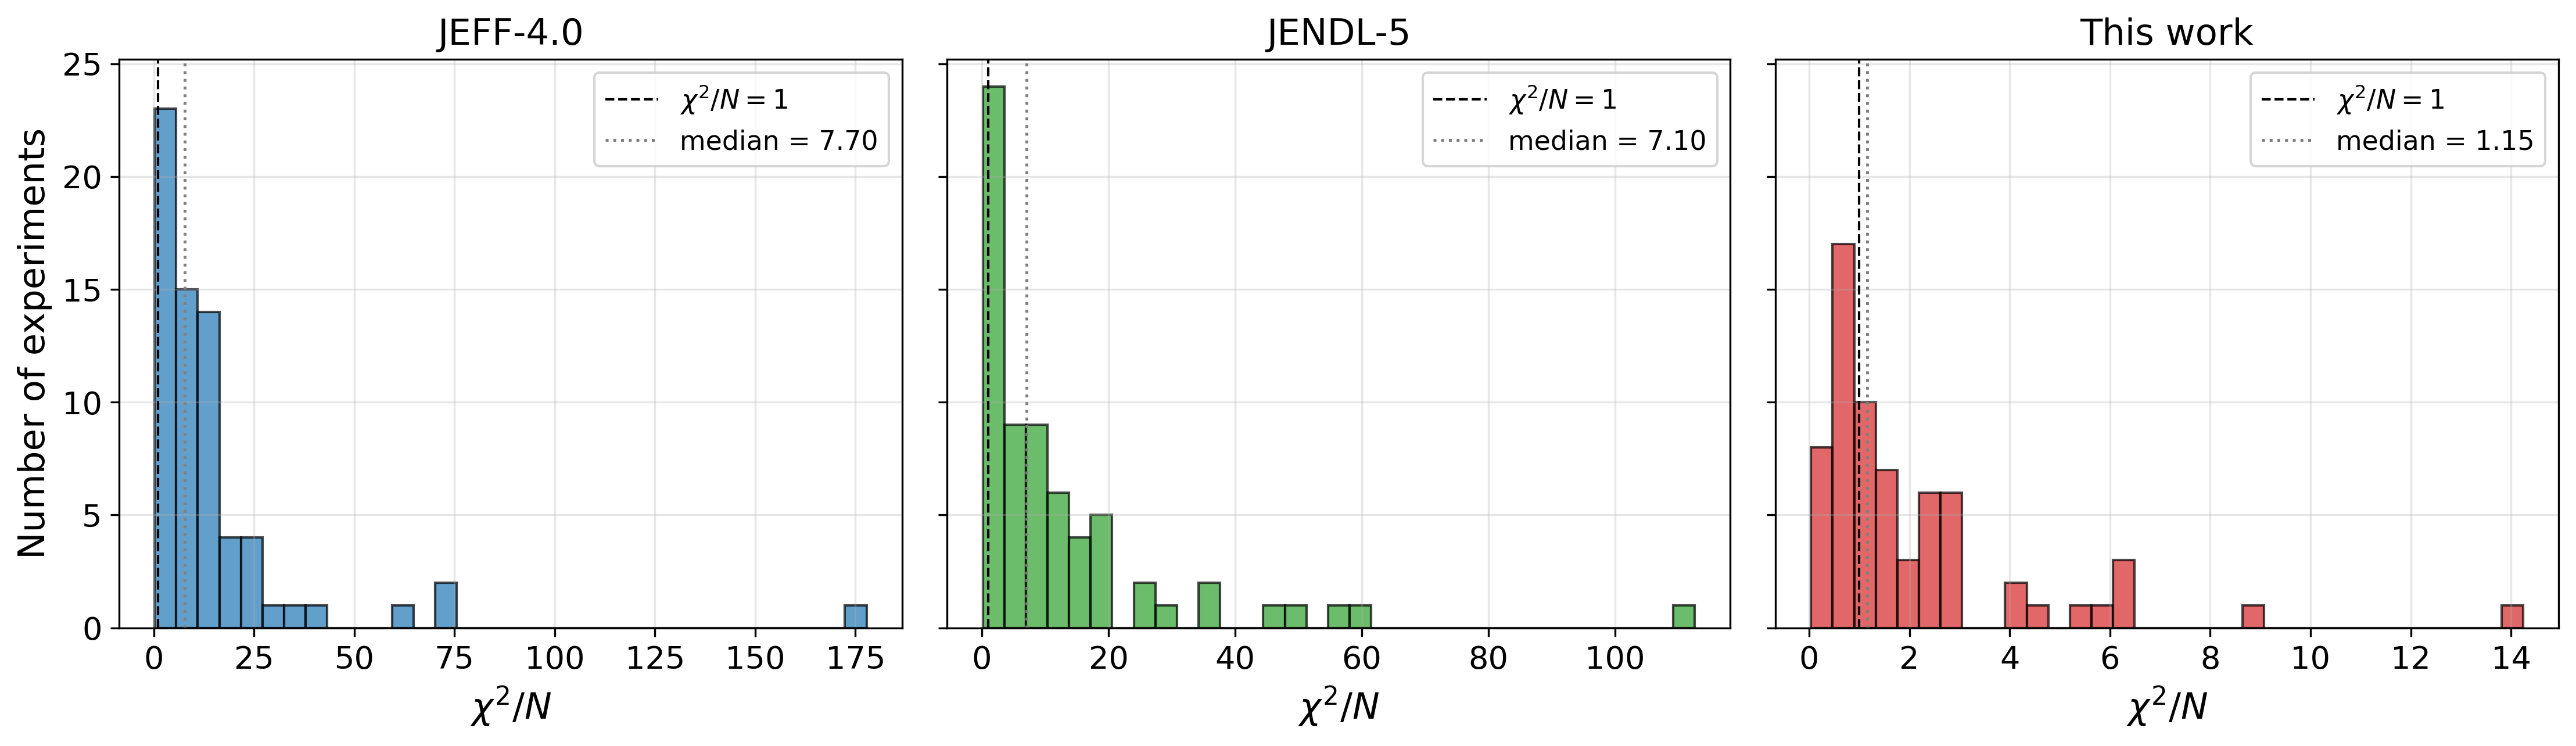

In [9]:
# ── Per-experiment chi2/N distribution (3-panel histogram) ────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, lib in zip(axes, LIBRARIES):
    vals = exp_df.loc[exp_df['library'] == lib, 'chi2/N'].dropna()
    median_val = vals.median()

    ax.hist(vals, bins=max(5, len(vals) // 2), color=LIB_COLORS[lib],
            edgecolor='k', alpha=0.7)
    ax.axvline(1.0, color='k', ls='--', lw=1, label=r'$\chi^2/N=1$')
    ax.axvline(median_val, color='gray', ls=':', lw=1.2,
               label=f'median = {median_val:.2f}')
    ax.set_xlabel(r'$\chi^2/N$')
    ax.set_title(LIB_LABELS[lib])
    ax.legend(fontsize=11)

axes[0].set_ylabel('Number of experiments')
fig.tight_layout()
save_fig(fig, 'chi2_per_experiment_histogram')
plt.show()

Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/chi2_contribution_per_experiment.png


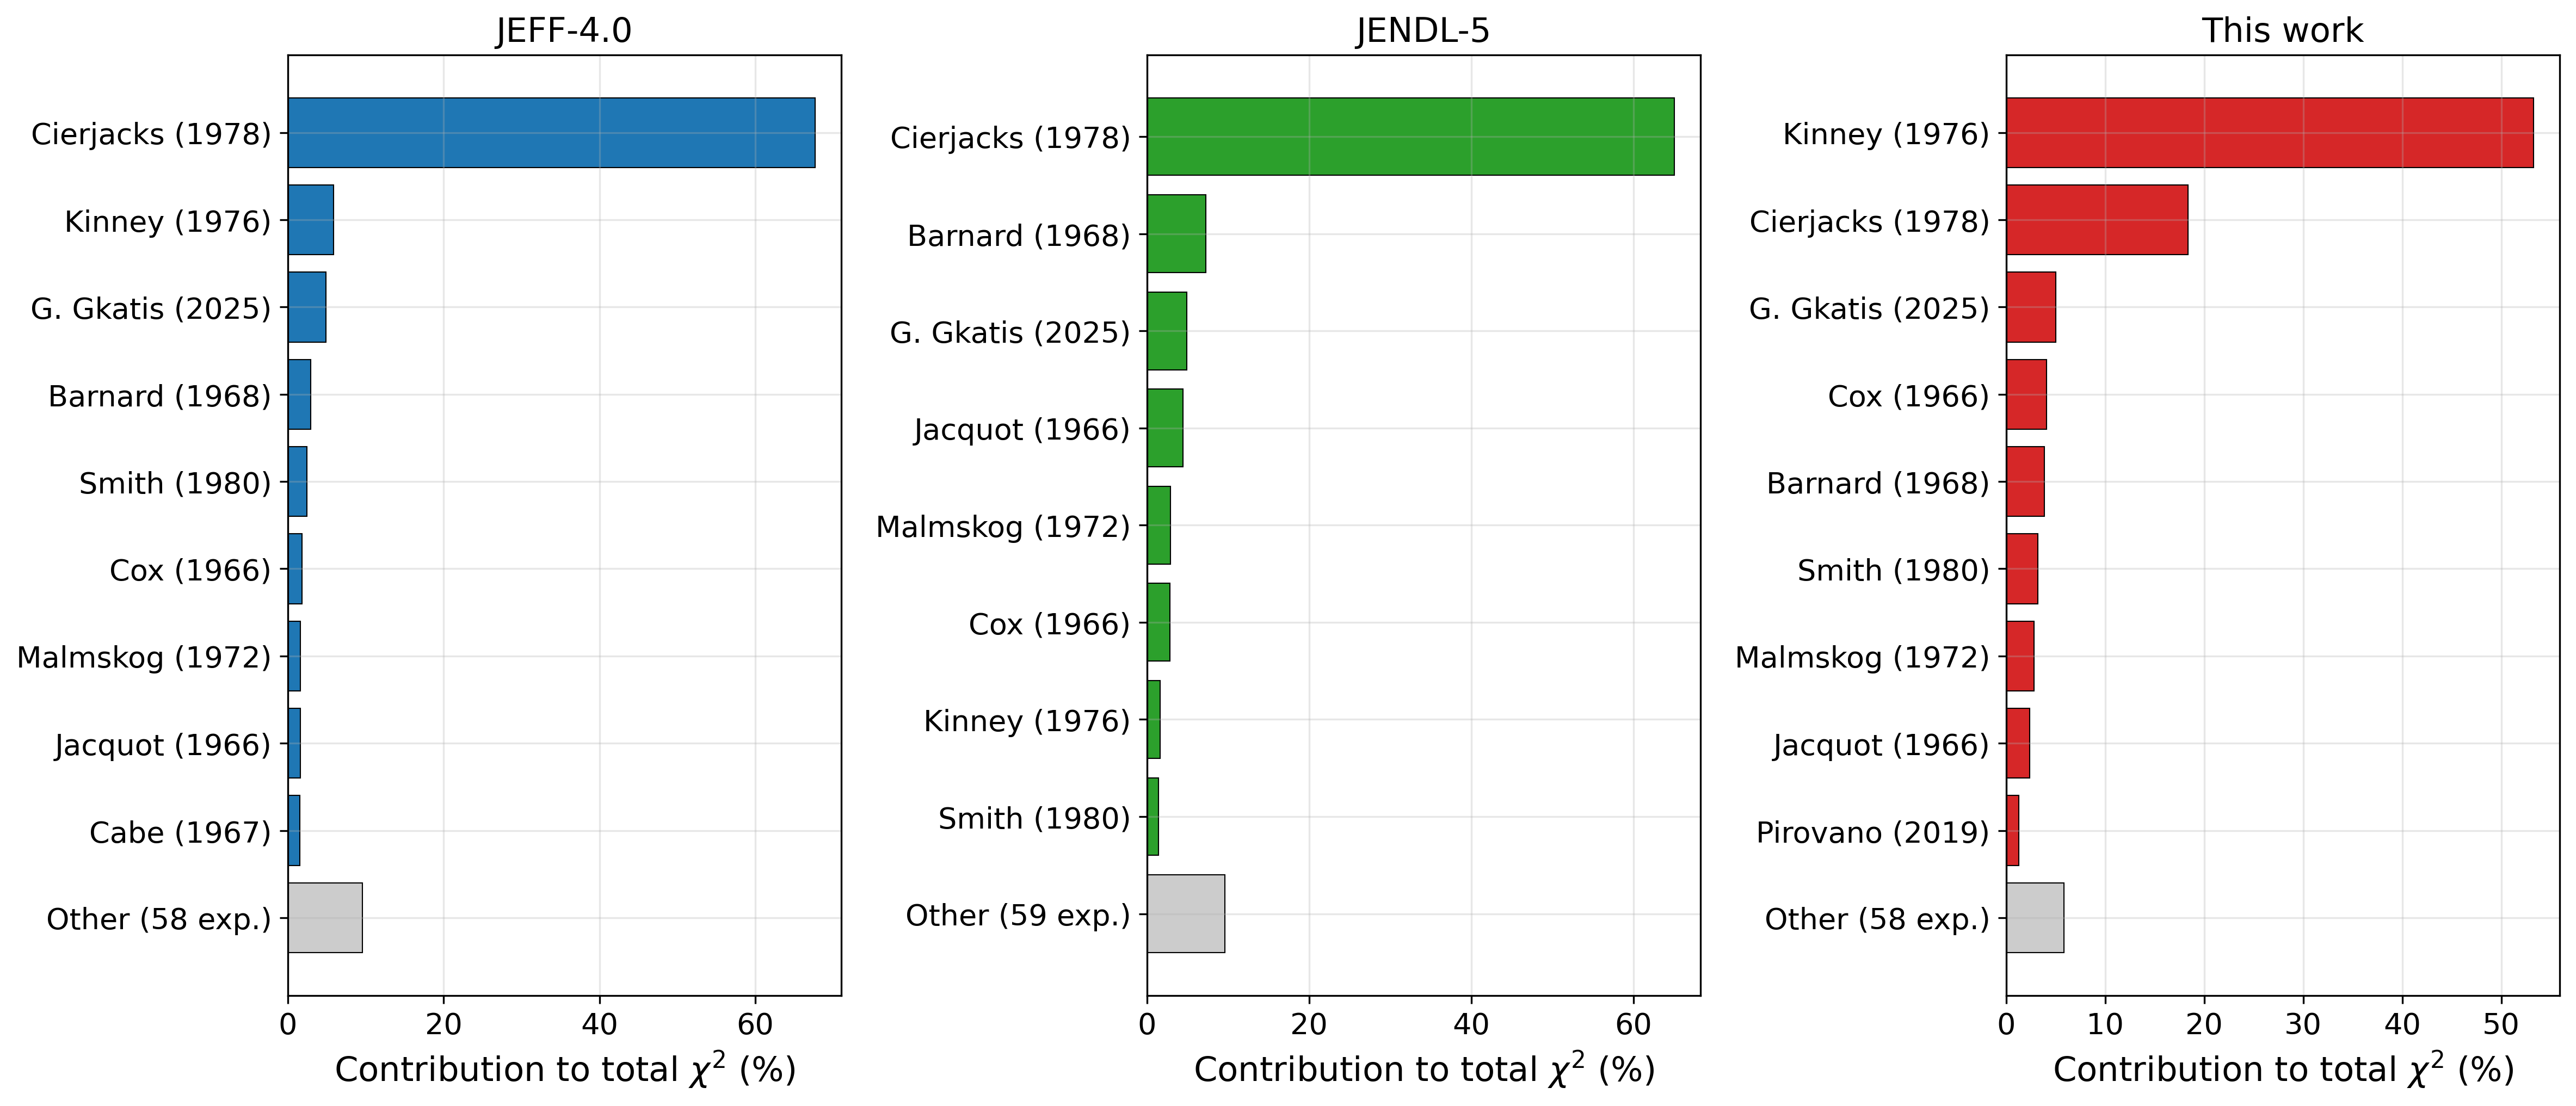

In [10]:
# ── Chi2 contribution % per experiment (3-panel horizontal bar) ───────────────
# Only show experiments contributing >= CONTRIB_THRESHOLD % to the total chi2

CONTRIB_THRESHOLD = 1.0  # percent

fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=False)

for ax, lib in zip(axes, LIBRARIES):
    sub = exp_df[exp_df['library'] == lib].copy()
    total_chi2 = sub['chi2_total'].sum()
    sub['contribution_pct'] = 100.0 * sub['chi2_total'] / total_chi2

    # Filter to experiments above threshold
    above = sub[sub['contribution_pct'] >= CONTRIB_THRESHOLD].copy()
    below = sub[sub['contribution_pct'] < CONTRIB_THRESHOLD]
    n_below = len(below)
    pct_below = below['contribution_pct'].sum()

    above = above.sort_values('contribution_pct', ascending=True)
    labels = [f"{r['author']} ({r['year']})" for _, r in above.iterrows()]

    # Add a summary bar for all experiments below threshold
    if n_below > 0:
        labels = [f'Other ({n_below} exp.)'] + labels
        values = [pct_below] + above['contribution_pct'].tolist()
        colors = ['#cccccc'] + [LIB_COLORS[lib]] * len(above)
    else:
        values = above['contribution_pct'].tolist()
        colors = [LIB_COLORS[lib]] * len(above)

    ax.barh(labels, values, color=colors, edgecolor='k', linewidth=0.5)
    ax.set_xlabel(r'Contribution to total $\chi^2$ (%)')
    ax.set_title(LIB_LABELS[lib])

fig.tight_layout()
save_fig(fig, 'chi2_contribution_per_experiment')
plt.show()

Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/chi2_waterfall.png


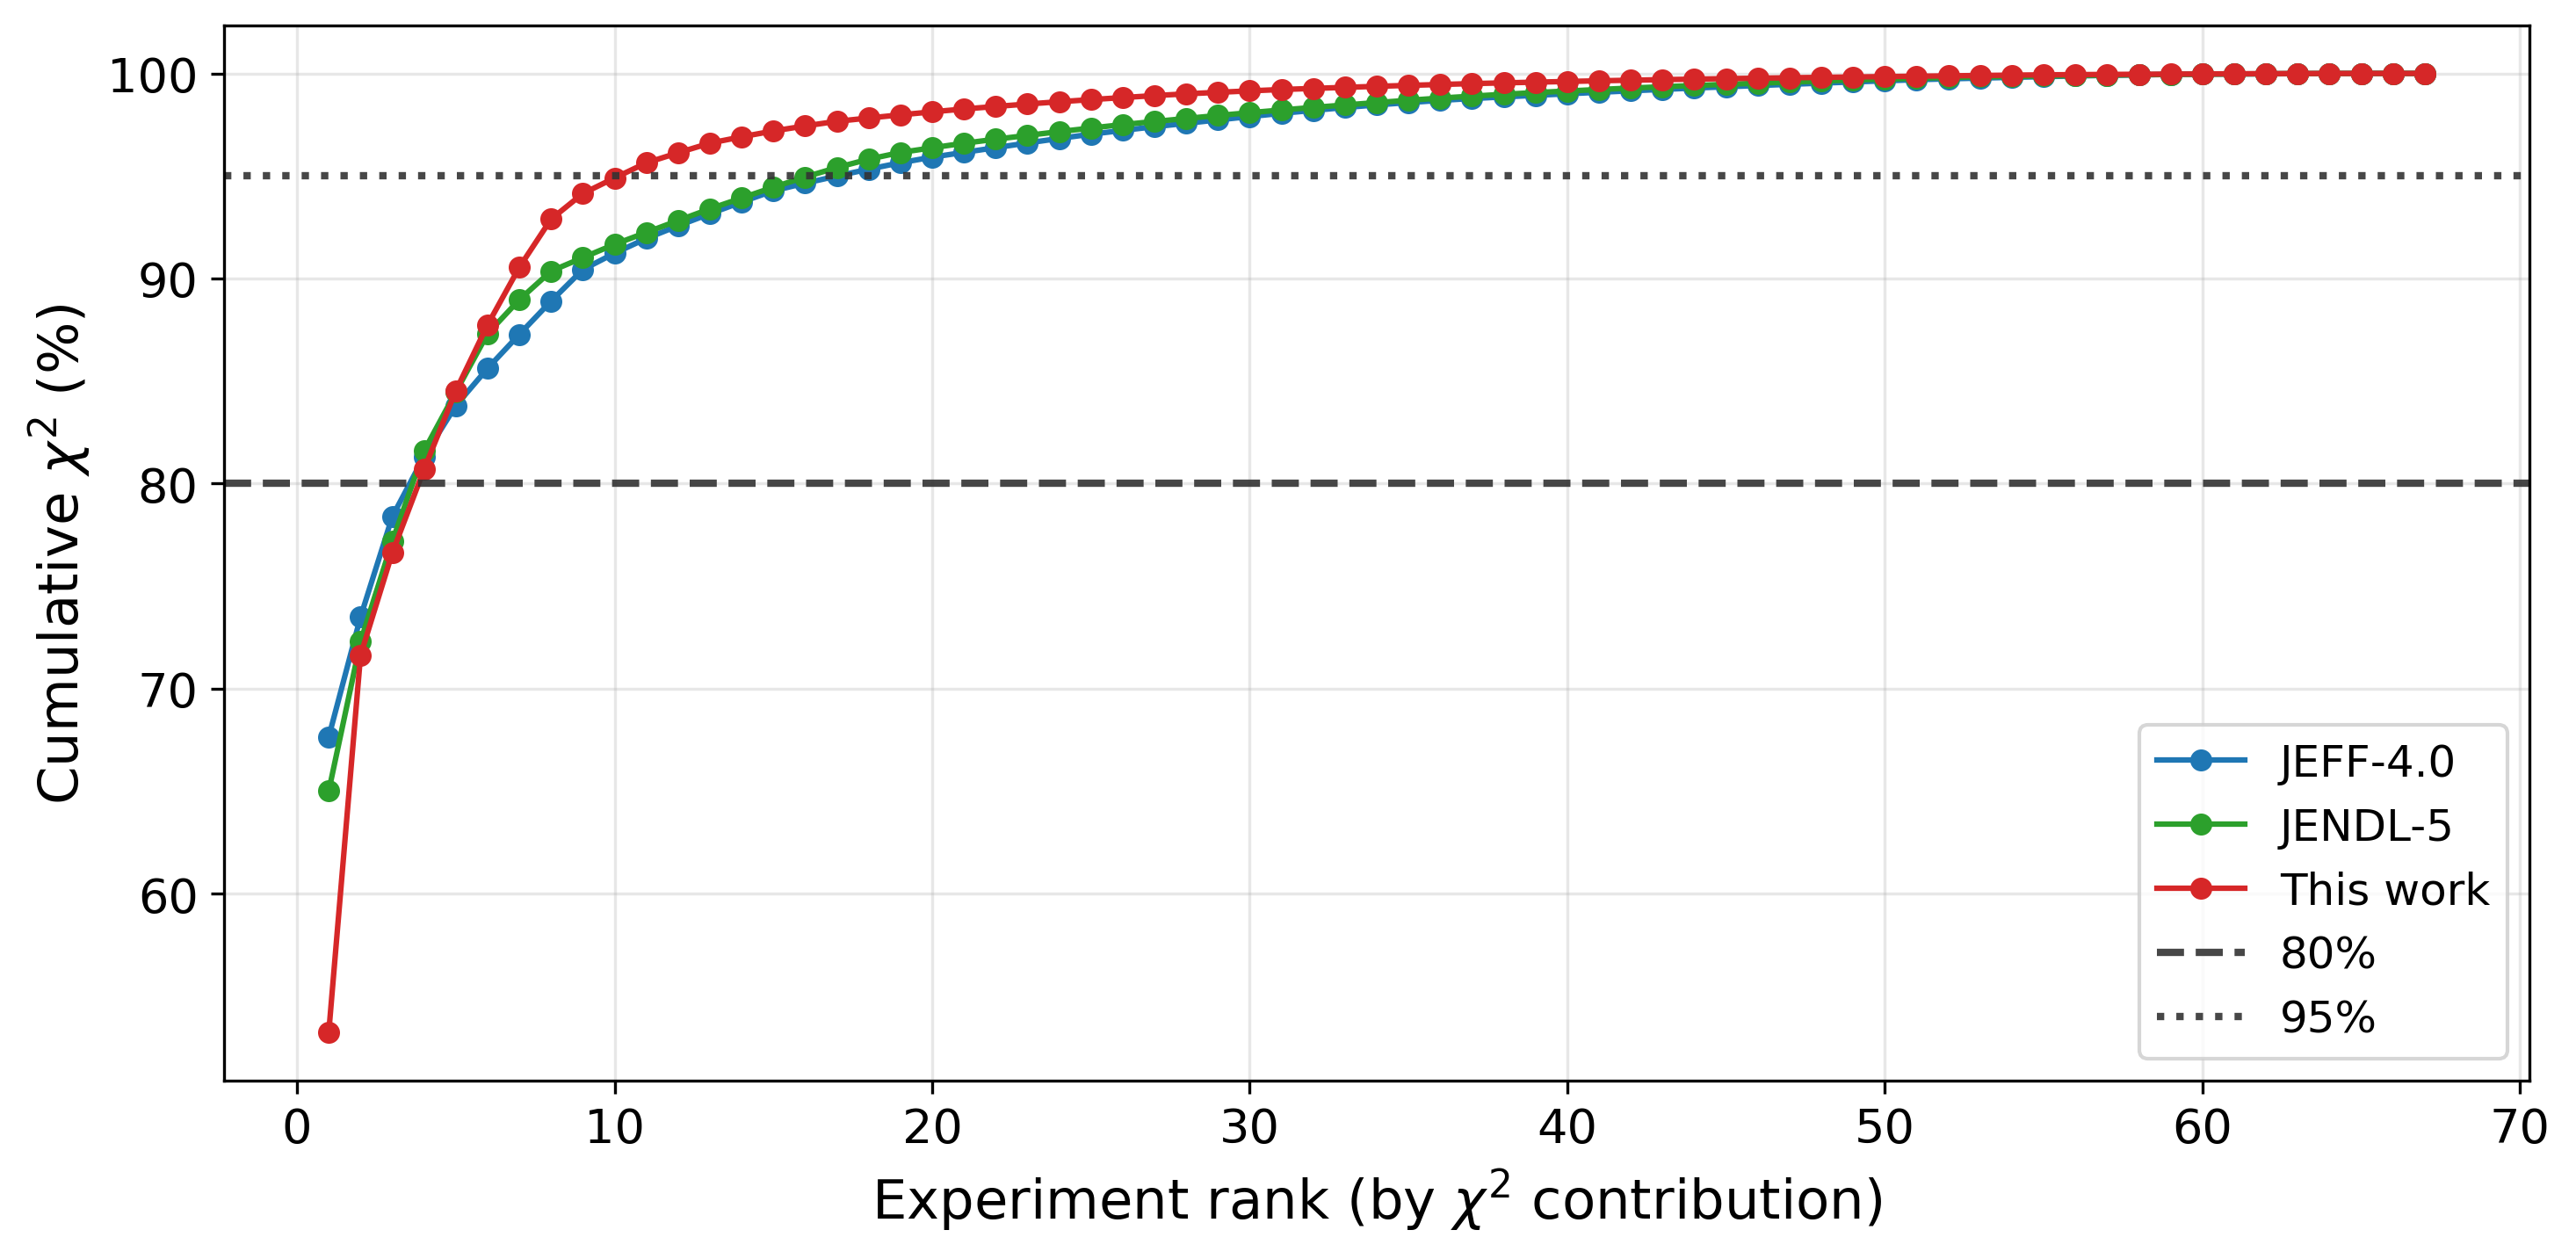

In [25]:
# ── Cumulative chi2 waterfall (all libraries overlaid) ────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

for lib in LIBRARIES:
    sub = exp_df[exp_df['library'] == lib].copy()
    total_chi2 = sub['chi2_total'].sum()
    sub = sub.sort_values('chi2_total', ascending=False).reset_index(drop=True)
    sub['cum_pct'] = 100.0 * sub['chi2_total'].cumsum() / total_chi2
    ax.plot(range(1, len(sub) + 1), sub['cum_pct'], 'o-',
            color=LIB_COLORS[lib], label=LIB_LABELS[lib], markersize=5)

# Make horizontal reference lines more visible
ax.axhline(80, color='#333333', ls='--', lw=2.0, alpha=0.9, label='80%', zorder=2.5)
ax.axhline(95, color='#333333', ls=':', lw=2.0, alpha=0.9, label='95%', zorder=2.5)
ax.set_xlabel('Experiment rank (by $\\chi^2$ contribution)')
ax.set_ylabel(r'Cumulative $\chi^2$ (%)')
ax.legend()
fig.tight_layout()
save_fig(fig, 'chi2_waterfall')
plt.show()

Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/chi2_vs_year.png


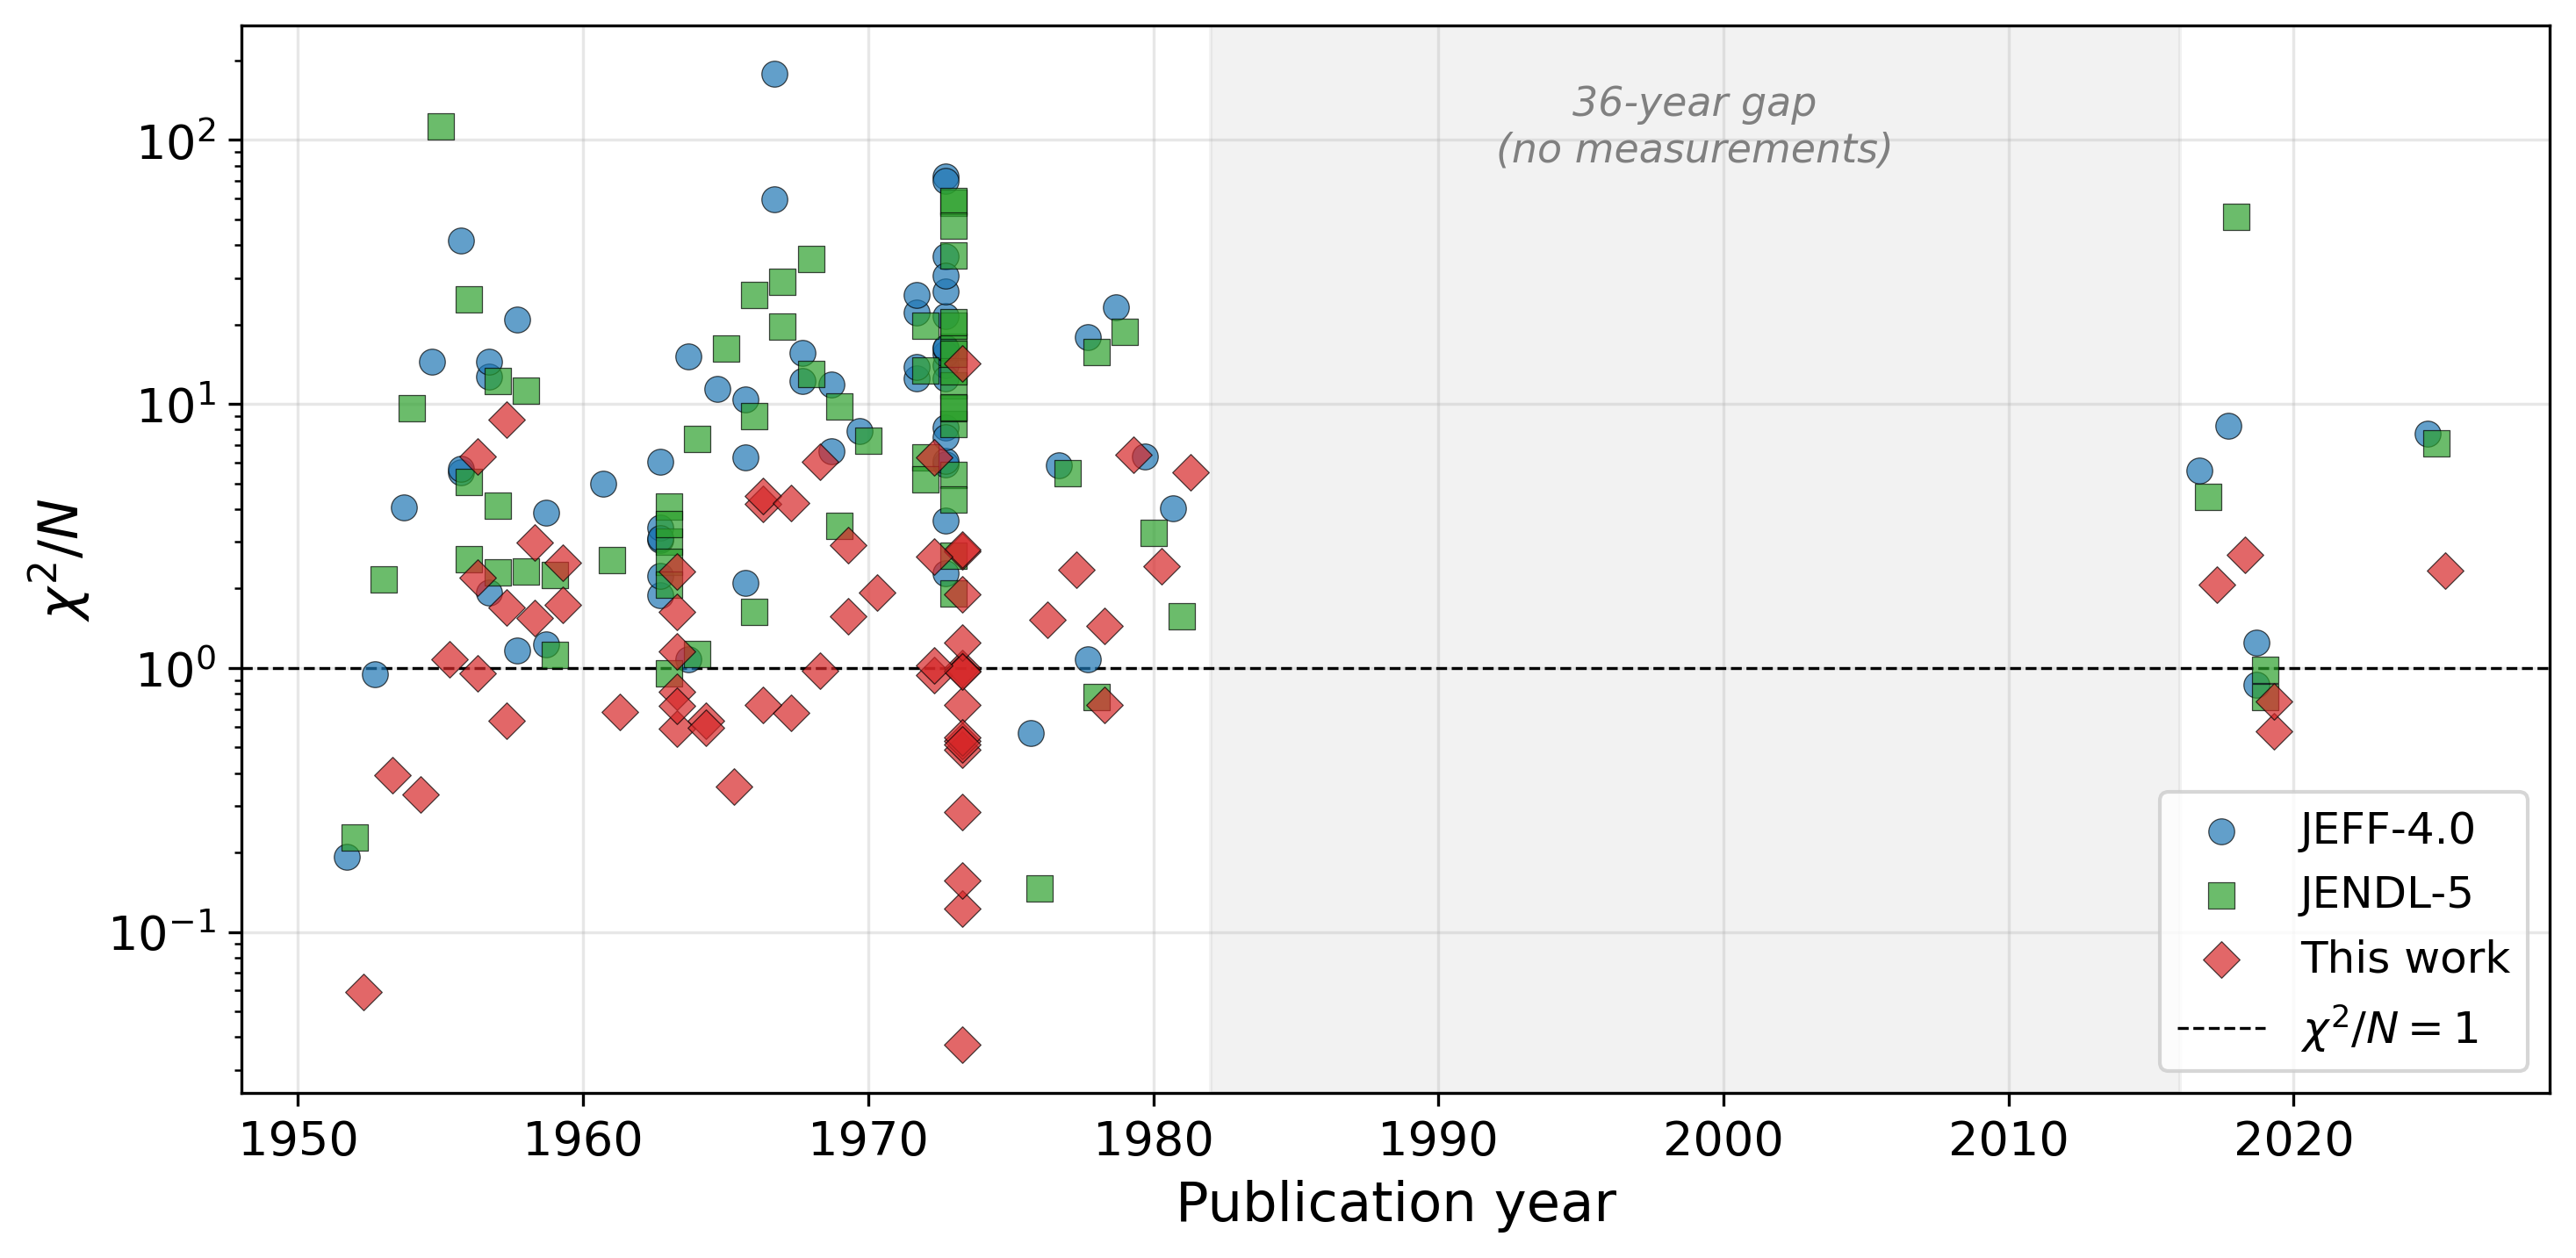

In [36]:
# ── Chi2/N vs publication year (per-experiment scatter) ───────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

# Offset markers slightly to avoid overlap
year_offsets = {'JEFF': -0.3, 'JENDL': 0.0, 'This_work': 0.3}
markers = {'JEFF': 'o', 'JENDL': 's', 'This_work': 'D'}

for lib in LIBRARIES:
    sub = exp_df[exp_df['library'] == lib].copy()
    sub['year_num'] = pd.to_numeric(sub['year'], errors='coerce')
    sub = sub.dropna(subset=['year_num'])
    offset = year_offsets[lib]

    ax.scatter(sub['year_num'] + offset, sub['chi2/N'],
               c=LIB_COLORS[lib], marker=markers[lib],
               s=50, alpha=0.7, edgecolors='k', linewidths=0.3,
               label=LIB_LABELS[lib], zorder=3)

# Shade the 1981-2017 measurement gap
ax.axvspan(1982, 2016, alpha=0.10, color='gray', zorder=0)
ax.annotate('36-year gap\n(no measurements)',
            xy=(1999, ax.get_ylim()[1] * 0.6),
            ha='center', va='center', fontsize=11,
            color='gray', fontstyle='italic')

ax.axhline(1.0, color='k', ls='--', lw=0.8, label=r'$\chi^2/N = 1$')
ax.set_xlabel('Publication year')
ax.set_ylabel(r'$\chi^2 / N$')
ax.set_yscale('log')
ax.legend()
fig.tight_layout()
save_fig(fig, 'chi2_vs_year')
plt.show()

## 3. Energy Dependence

Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/chi2_vs_energy.png


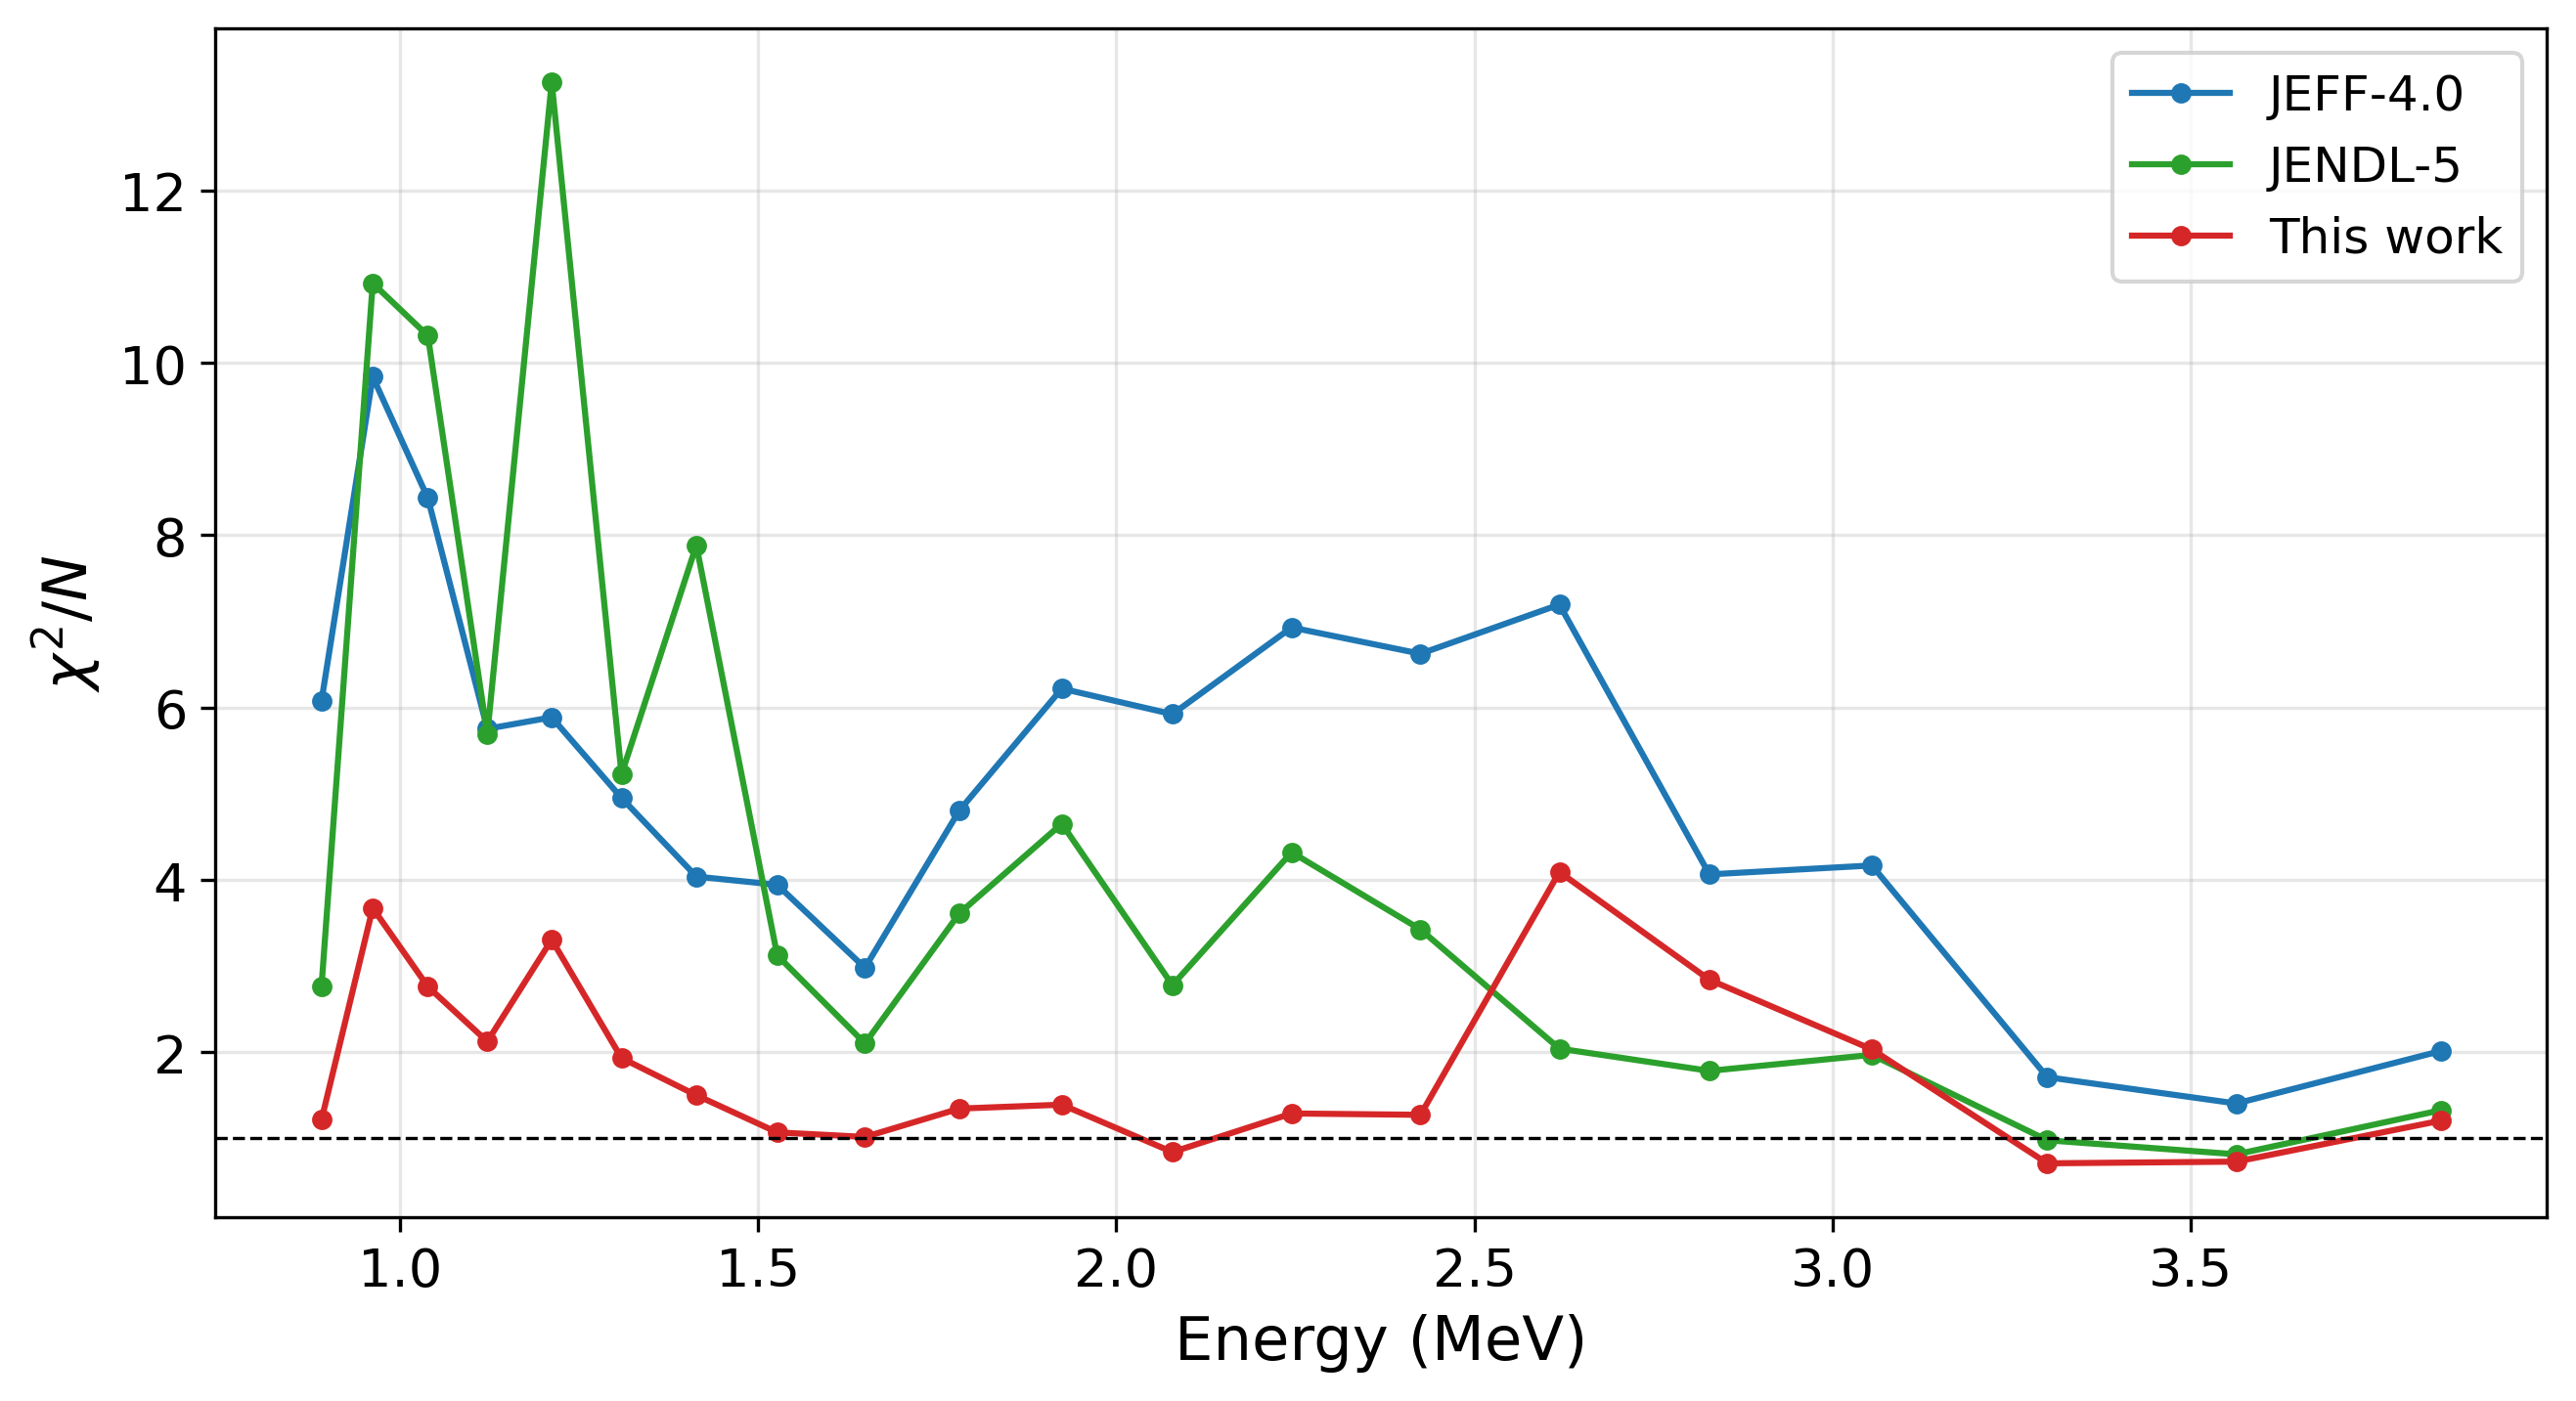

In [27]:
# ── Chi2/N vs energy (log-spaced bins) ───────────────────────────────────────

bin_edges = np.logspace(np.log10(E_MIN), np.log10(E_MAX), N_ENERGY_BINS + 1)
df['e_bin'] = pd.cut(df['energy_mev'], bins=bin_edges)
# Geometric midpoints
df['e_mid'] = df['e_bin'].apply(
    lambda x: np.sqrt(x.left * x.right) if pd.notna(x) else np.nan
)

fig, ax = plt.subplots(figsize=(9, 5))

for lib in LIBRARIES:
    sub = df[df['library'] == lib]
    grouped = sub.groupby('e_bin', observed=True)
    chi2_n = grouped['chi2'].sum() / grouped['chi2'].count()
    midpoints = grouped['e_mid'].first().values
    ax.plot(midpoints, chi2_n.values, 'o-', color=LIB_COLORS[lib],
            label=LIB_LABELS[lib], markersize=4, linewidth=1.5)

ax.axhline(1.0, color='k', ls='--', lw=0.8)
ax.set_xscale('linear')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel(r'$\chi^2 / N$')
ax.legend()
fig.tight_layout()
save_fig(fig, 'chi2_vs_energy')
plt.show()

Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/chi2_cumulative_vs_energy.png


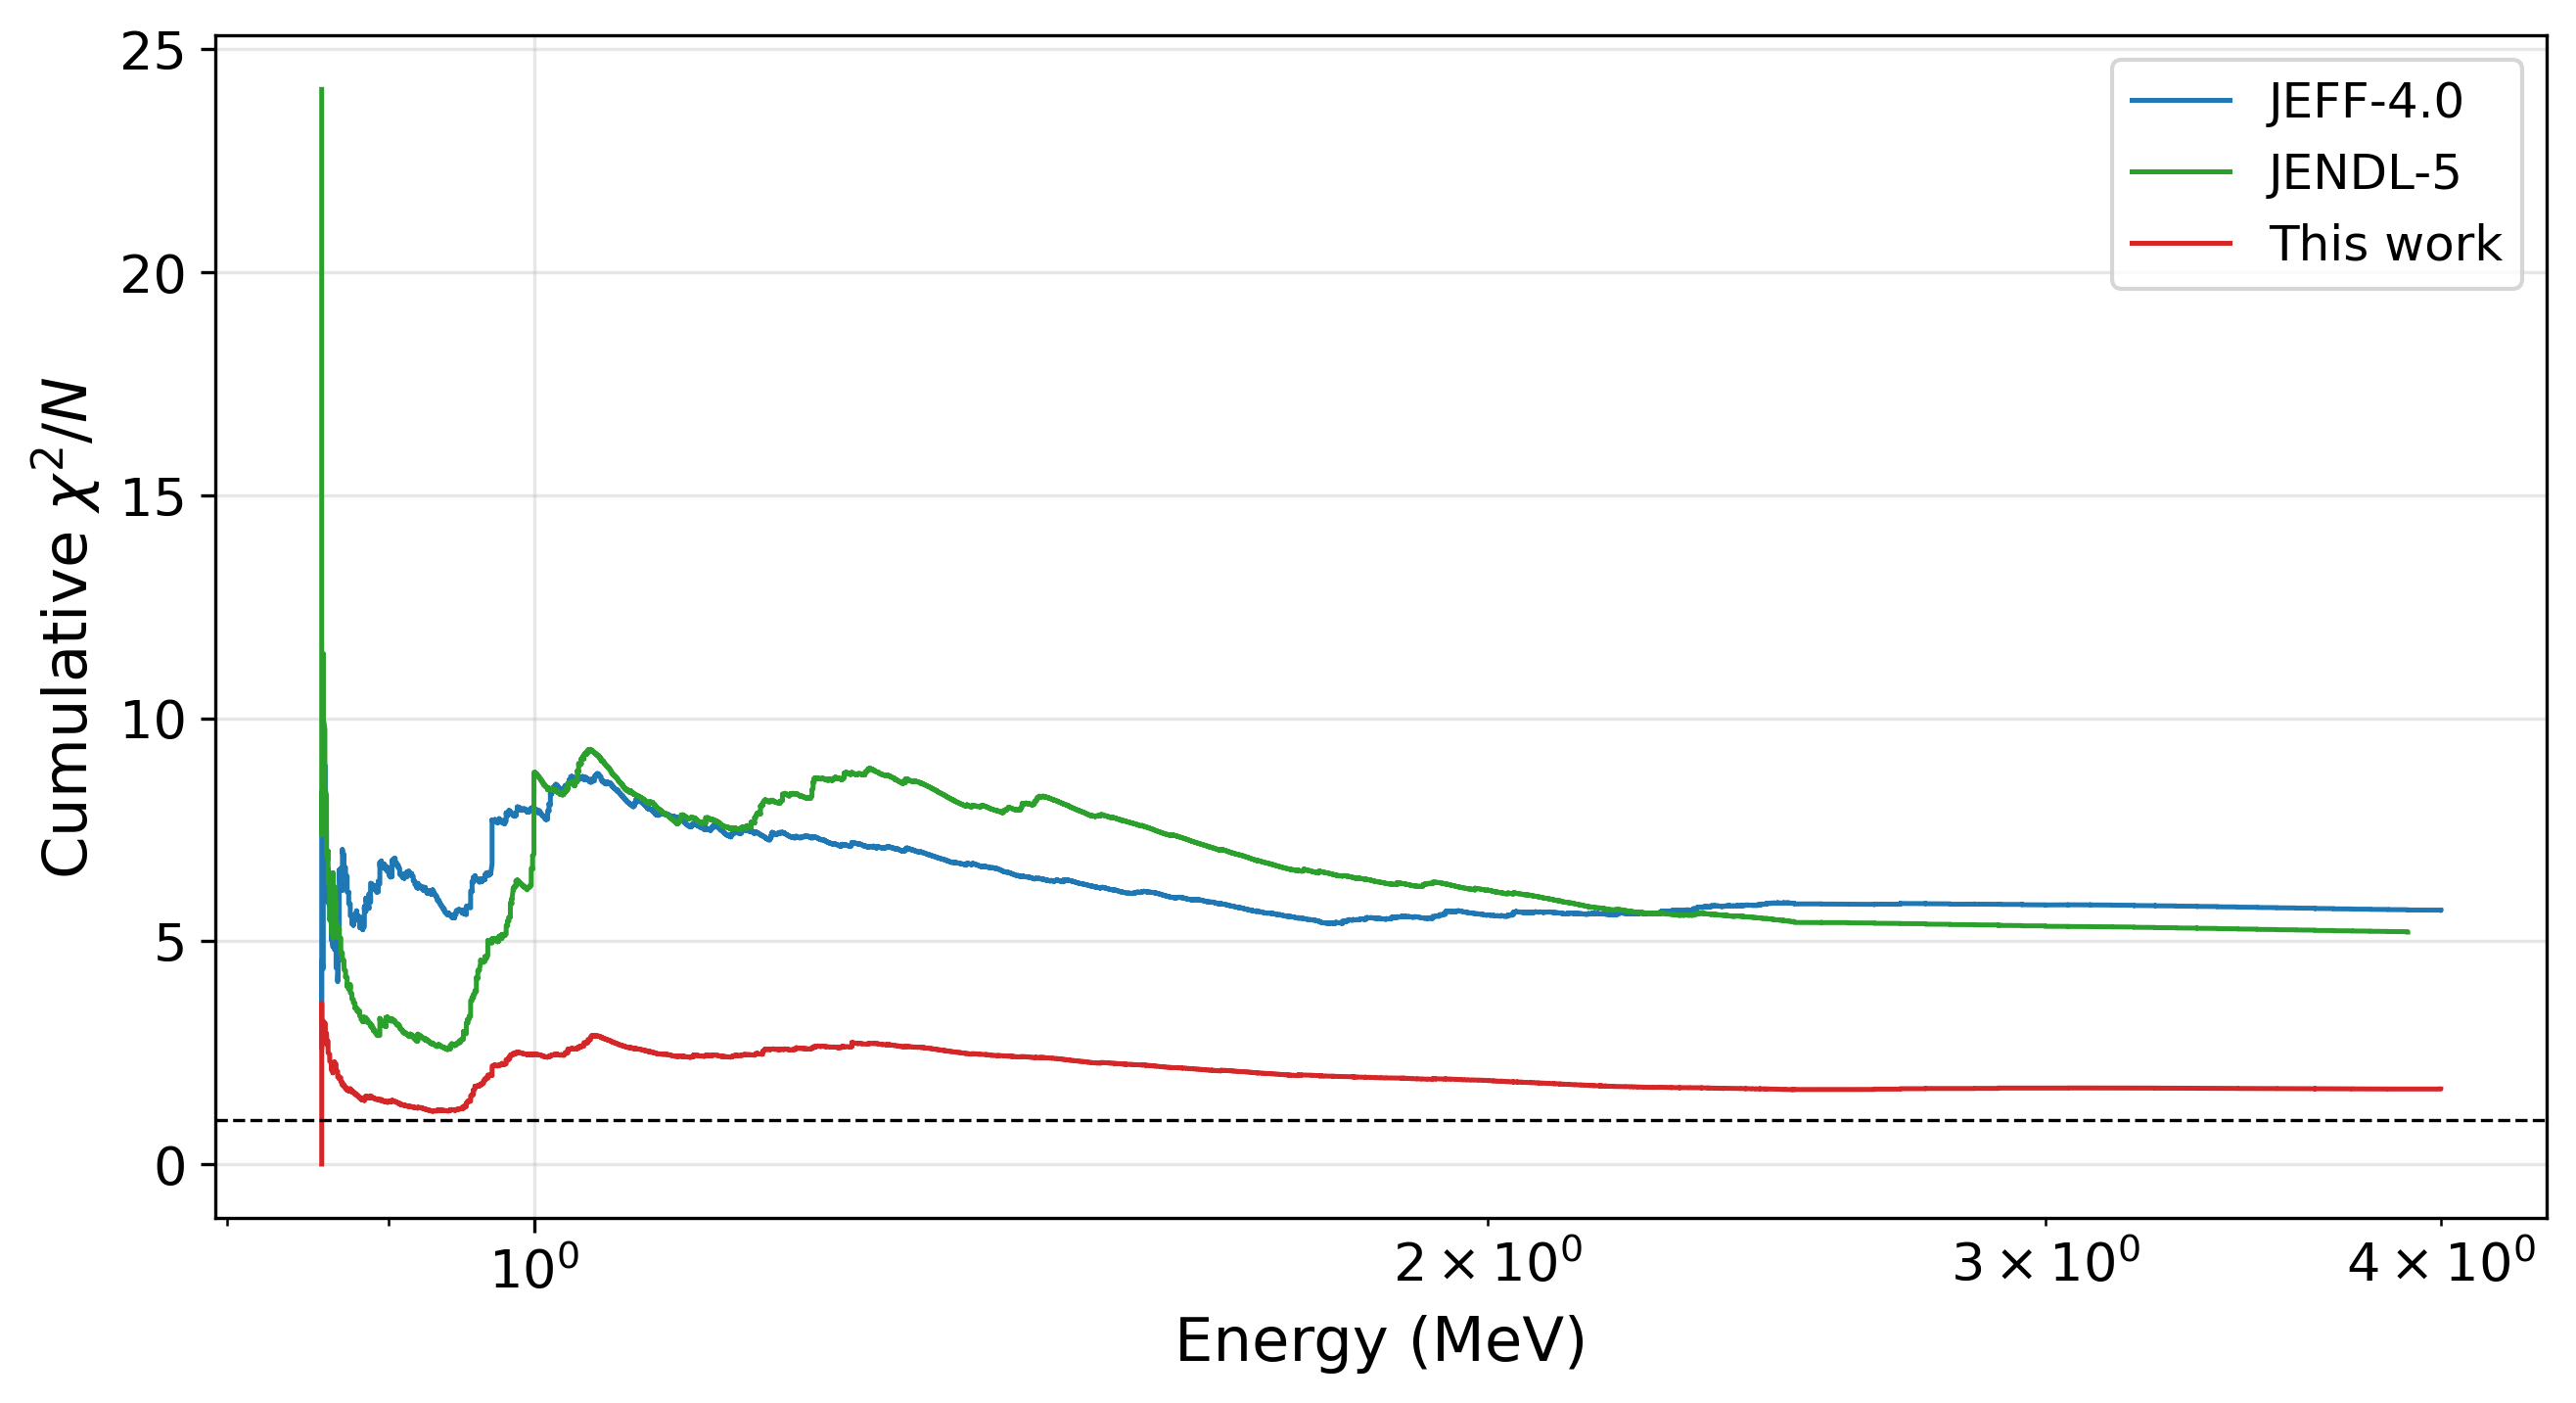

In [28]:
# ── Running cumulative chi2/N vs energy ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

for lib in LIBRARIES:
    sub = df[df['library'] == lib].sort_values('energy_mev').reset_index(drop=True)
    cum_chi2 = sub['chi2'].cumsum()
    cum_n = np.arange(1, len(sub) + 1)
    cum_reduced = cum_chi2 / cum_n
    ax.plot(sub['energy_mev'], cum_reduced, color=LIB_COLORS[lib],
            label=LIB_LABELS[lib], linewidth=1.2)

ax.axhline(1.0, color='k', ls='--', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel(r'Cumulative $\chi^2 / N$')
ax.legend()
fig.tight_layout()
save_fig(fig, 'chi2_cumulative_vs_energy')
plt.show()

## 4. Residual Diagnostics

In [29]:
# ── Residual statistics table ─────────────────────────────────────────────────

res_stats = []
for lib in LIBRARIES:
    r = df.loc[df['library'] == lib, 'residual'].values
    res_stats.append({
        'Library': LIB_LABELS[lib],
        'mean': np.mean(r),
        'std': np.std(r, ddof=1),
        'skewness': stats.skew(r),
        'kurtosis': stats.kurtosis(r),
        '|r|>2 (%)': 100.0 * np.mean(np.abs(r) > 2),
        '|r|>3 (%)': 100.0 * np.mean(np.abs(r) > 3),
    })

res_df = pd.DataFrame(res_stats)
print("Residual statistics (expected for N(0,1): mean=0, std=1, "
      "skew=0, kurt=0, |r|>2: 4.6%, |r|>3: 0.3%)\n")
print(res_df.to_string(index=False, float_format='%.3f'))

Residual statistics (expected for N(0,1): mean=0, std=1, skew=0, kurt=0, |r|>2: 4.6%, |r|>3: 0.3%)

  Library   mean   std  skewness  kurtosis  |r|>2 (%)  |r|>3 (%)
 JEFF-4.0 -0.052 2.385     0.277     9.633     17.903     12.464
  JENDL-5 -0.080 2.280    -0.817    15.583     18.431     11.684
This work  0.101 1.295     0.151     7.115     10.644      3.551


Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/residual_histograms.png


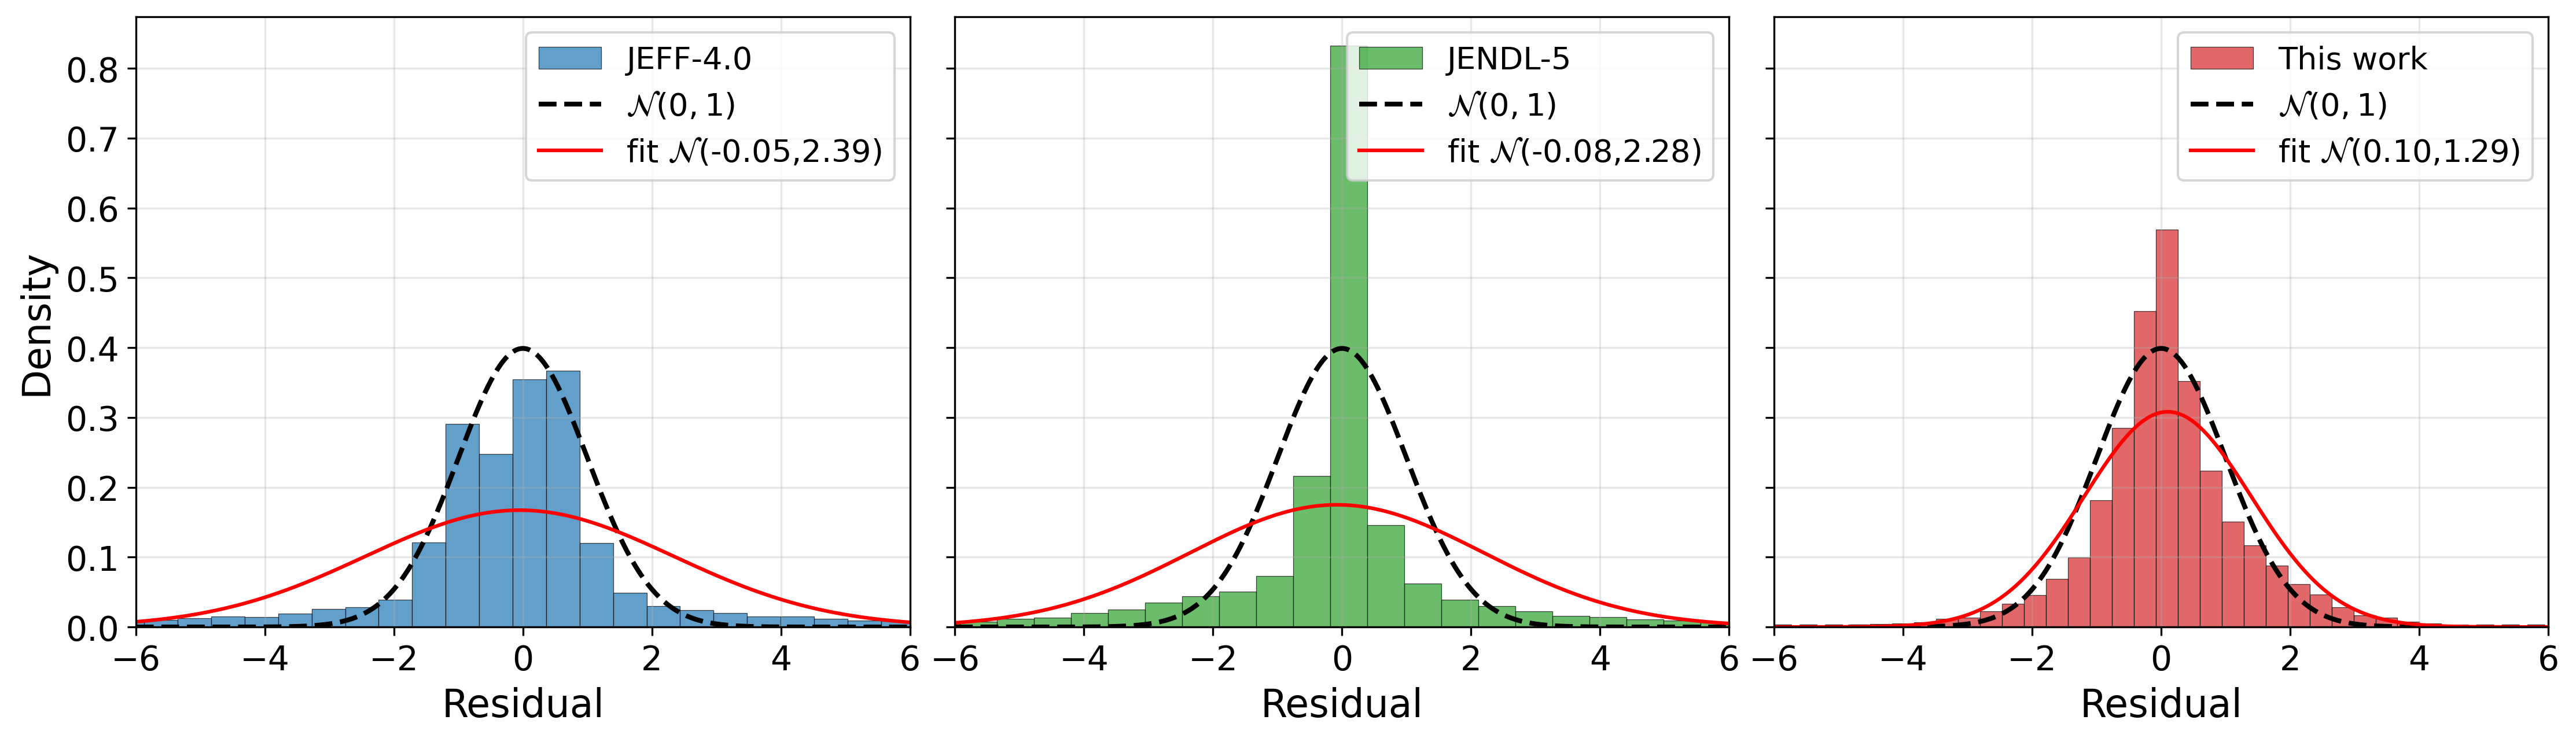

In [30]:
# ── Residual histograms with N(0,1) overlay ──────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

x_grid = np.linspace(-6, 6, 300)

for ax, lib in zip(axes, LIBRARIES):
    r = df.loc[df['library'] == lib, 'residual'].values
    mu_fit, sigma_fit = stats.norm.fit(r)

    ax.hist(r, bins=80, density=True, color=LIB_COLORS[lib],
            edgecolor='k', linewidth=0.3, alpha=0.7, label=LIB_LABELS[lib])
    ax.plot(x_grid, stats.norm.pdf(x_grid, 0, 1), 'k--', lw=2.0,
            label='$\\mathcal{N}(0,1)$')
    ax.plot(x_grid, stats.norm.pdf(x_grid, mu_fit, sigma_fit), 'r-', lw=1.5,
            label=f'fit $\\mathcal{{N}}$({mu_fit:.2f},{sigma_fit:.2f})')
    ax.set_xlabel('Residual', fontsize=16)
    ax.set_xlim(-6, 6)
    ax.legend(fontsize=13)
    ax.tick_params(labelsize=14)

axes[0].set_ylabel('Density', fontsize=16)
fig.tight_layout()
save_fig(fig, 'residual_histograms')
plt.show()

Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/residual_qq_plots.png


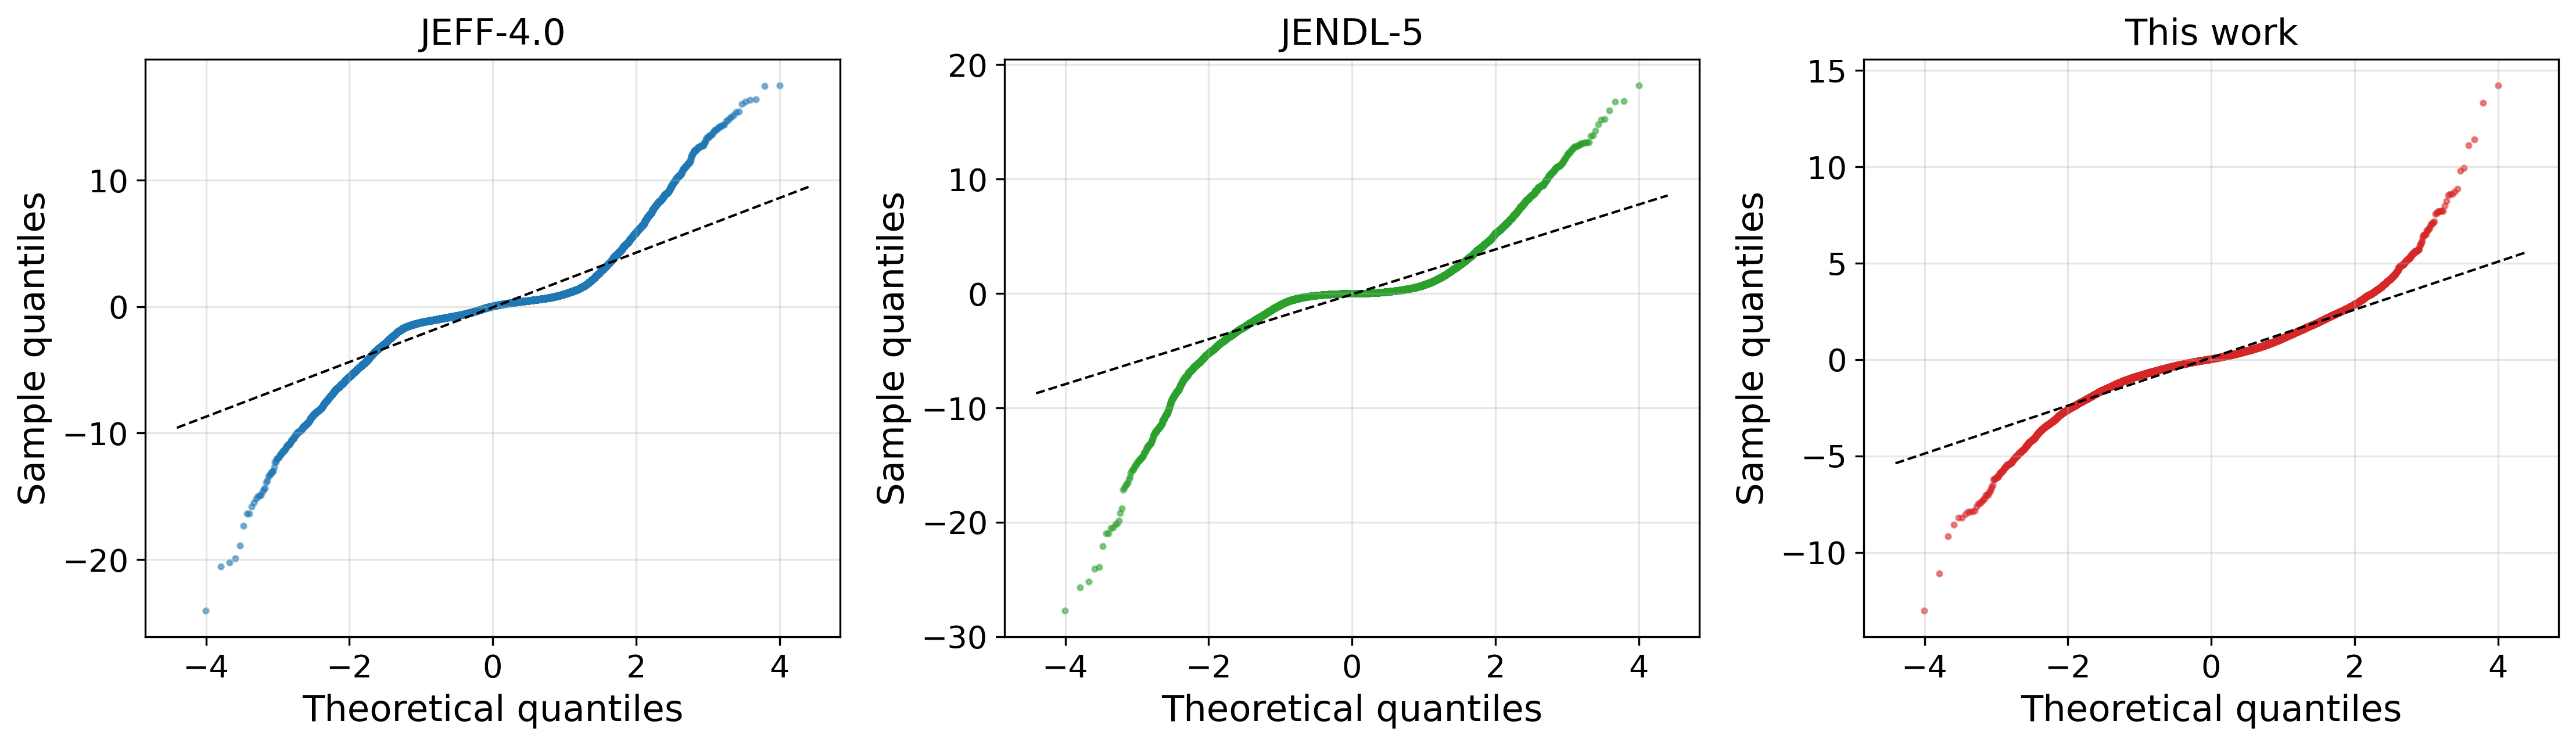

In [31]:
# ── Q-Q plots ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, lib in zip(axes, LIBRARIES):
    r = df.loc[df['library'] == lib, 'residual'].values
    (osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
    ax.scatter(osm, osr, s=4, alpha=0.5, color=LIB_COLORS[lib], rasterized=True)
    xlim = ax.get_xlim()
    ax.plot(xlim, [slope * x + intercept for x in xlim], 'k--', lw=1)
    ax.set_xlabel('Theoretical quantiles')
    ax.set_ylabel('Sample quantiles')
    ax.set_title(LIB_LABELS[lib])

fig.tight_layout()
save_fig(fig, 'residual_qq_plots')
plt.show()

Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/residual_vs_energy.png


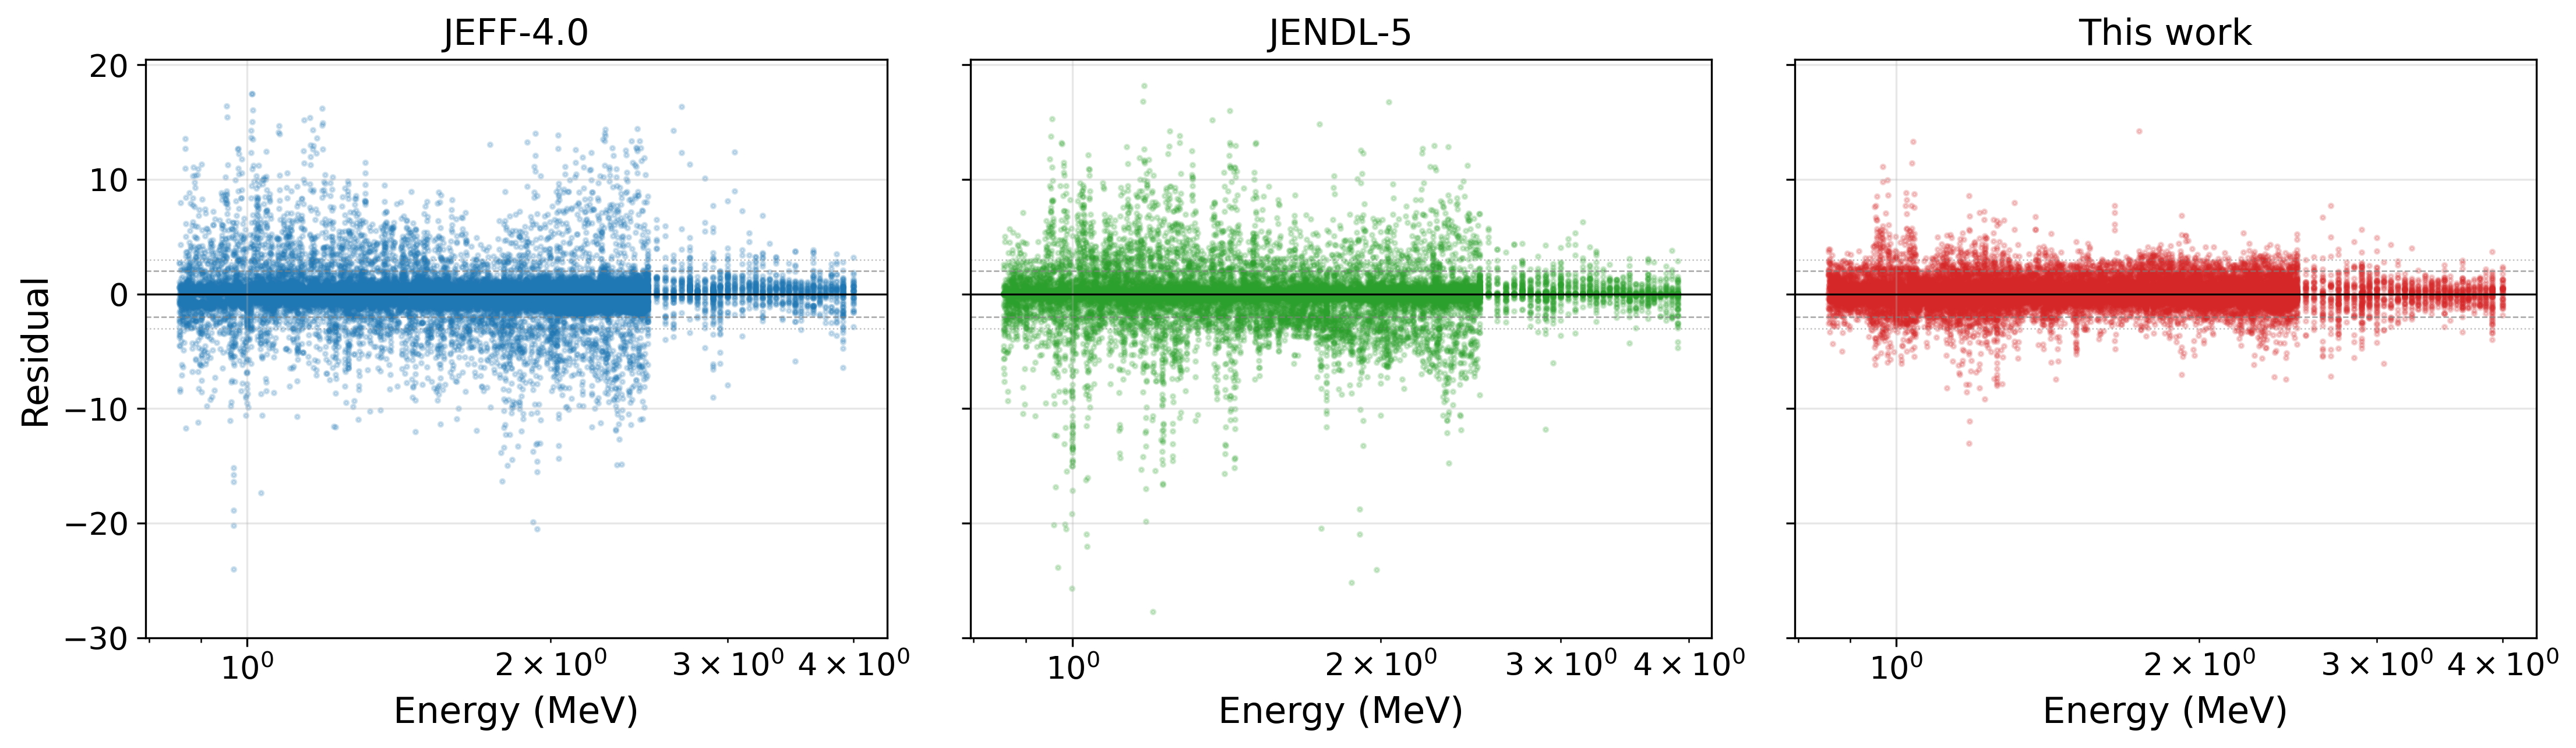

In [32]:
# ── Residual vs energy scatter ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, lib in zip(axes, LIBRARIES):
    sub = df[df['library'] == lib]
    ax.scatter(sub['energy_mev'], sub['residual'], s=3, alpha=0.2,
               color=LIB_COLORS[lib], rasterized=True)
    ax.axhline(0, color='k', lw=0.8)
    ax.axhline(2, color='gray', ls='--', lw=0.6, alpha=0.7)
    ax.axhline(-2, color='gray', ls='--', lw=0.6, alpha=0.7)
    ax.axhline(3, color='gray', ls=':', lw=0.6, alpha=0.5)
    ax.axhline(-3, color='gray', ls=':', lw=0.6, alpha=0.5)
    ax.set_xscale('log')
    ax.set_xlabel('Energy (MeV)')
    ax.set_title(LIB_LABELS[lib])

axes[0].set_ylabel('Residual')
fig.tight_layout()
save_fig(fig, 'residual_vs_energy')
plt.show()

Saved: /share_snc/snc/JuanMonleon/DA_Figures/chi2/mean_residual_vs_energy.png


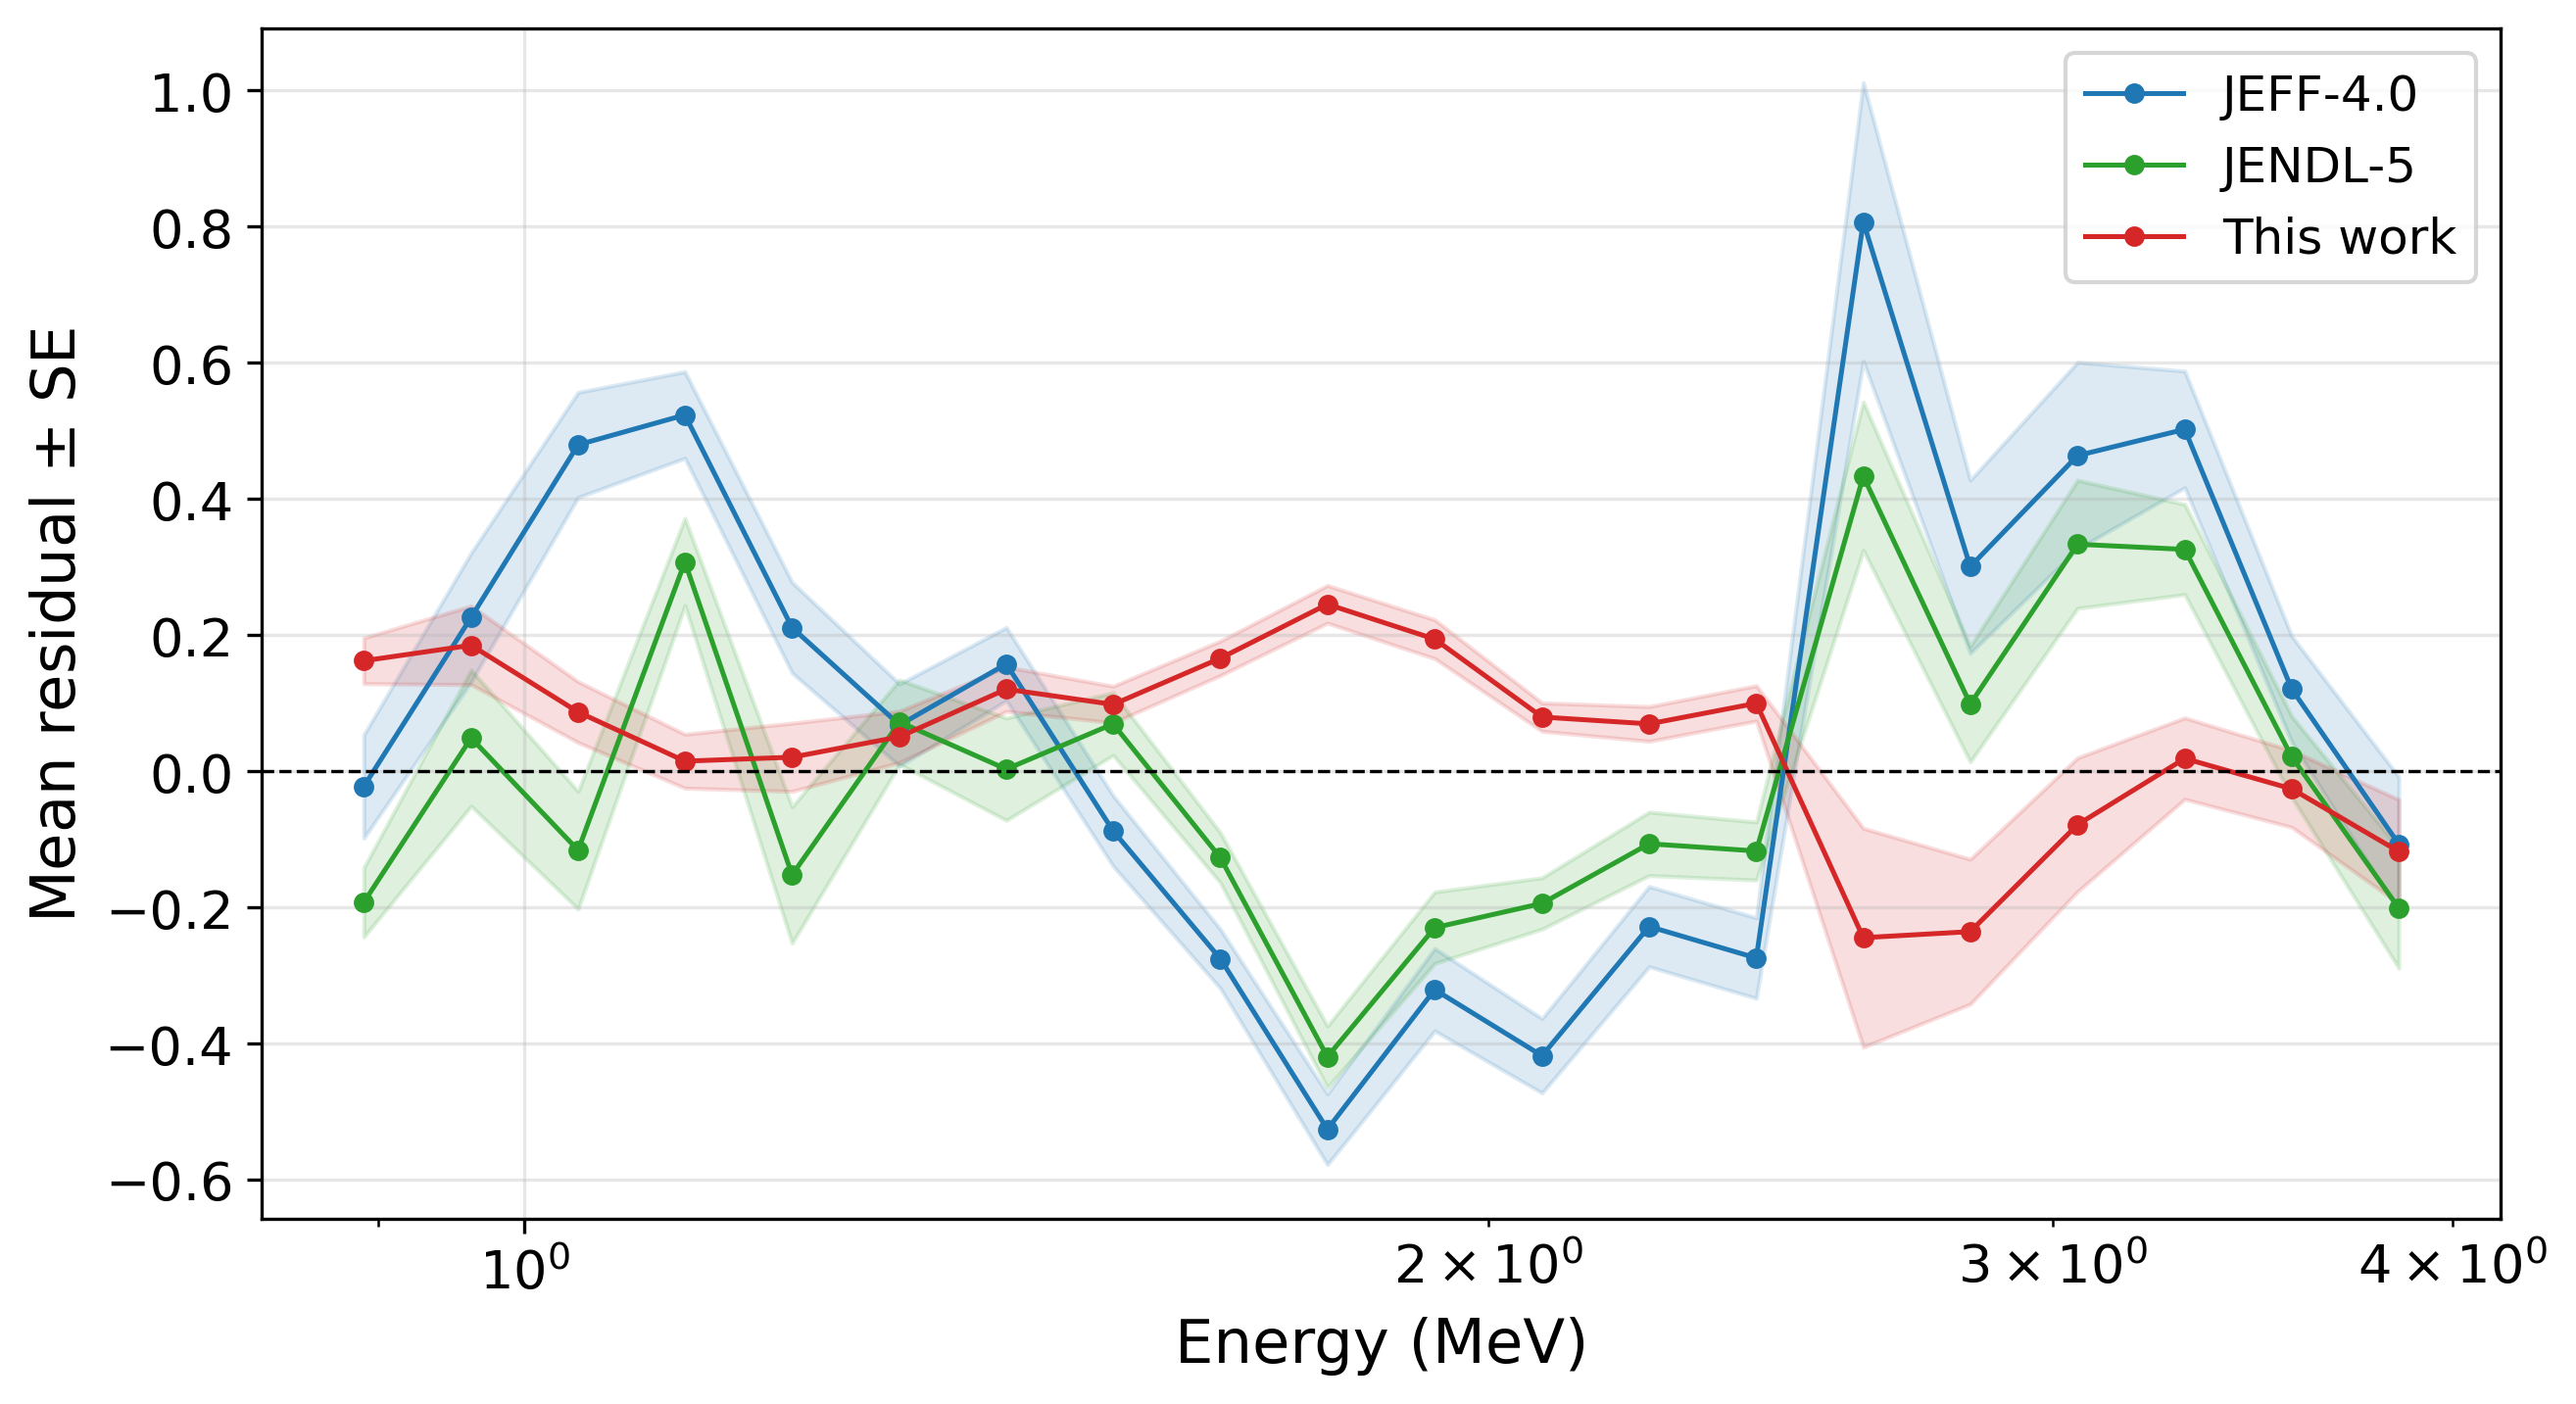

In [33]:
# ── Mean residual ± SE vs energy (bias diagnostic) ────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

for lib in LIBRARIES:
    sub = df[df['library'] == lib]
    grouped = sub.groupby('e_bin', observed=True)
    mean_r = grouped['residual'].mean()
    se_r = grouped['residual'].std() / np.sqrt(grouped['residual'].count())
    midpoints = grouped['e_mid'].first().values

    ax.plot(midpoints, mean_r.values, 'o-', color=LIB_COLORS[lib],
            label=LIB_LABELS[lib], markersize=4, linewidth=1.2)
    ax.fill_between(midpoints,
                    mean_r.values - se_r.values,
                    mean_r.values + se_r.values,
                    color=LIB_COLORS[lib], alpha=0.15)

ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel(r'Mean residual $\pm$ SE')
ax.legend()
fig.tight_layout()
save_fig(fig, 'mean_residual_vs_energy')
plt.show()

## 5. Summary

In [34]:
# ── Automated text summary ────────────────────────────────────────────────────

print("=" * 70)
print("AUTOMATED SUMMARY")
print("=" * 70)

# Global chi2/N ranking
print("\n--- Global chi2/N ranking ---")
for _, row in summary_df.sort_values('chi2/N').iterrows():
    print(f"  {row['Library']:12s}  chi2/N = {row['chi2/N']:.3f}  (N = {row['N']})")

best_lib = summary_df.loc[summary_df['chi2/N'].idxmin(), 'Library']
print(f"  -> Best overall: {best_lib}")

# Residual normality assessment
print("\n--- Residual normality assessment ---")
for lib in LIBRARIES:
    r = df.loc[df['library'] == lib, 'residual'].values
    mu, sigma = np.mean(r), np.std(r, ddof=1)
    pct_gt2 = 100.0 * np.mean(np.abs(r) > 2)
    issues = []
    if abs(mu) > 0.1:
        issues.append(f'bias={mu:.3f}')
    if sigma < 0.8 or sigma > 1.2:
        issues.append(f'width={sigma:.3f}')
    if pct_gt2 > 10:
        issues.append(f'outliers={pct_gt2:.1f}%')
    status = ', '.join(issues) if issues else 'OK'
    print(f"  {LIB_LABELS[lib]:12s}  mean={mu:+.3f}  std={sigma:.3f}  "
          f"|r|>2: {pct_gt2:.1f}%  [{status}]")

# Dominant experiment per library
print("\n--- Dominant experiment per library ---")
for lib in LIBRARIES:
    sub = exp_df[exp_df['library'] == lib].copy()
    total = sub['chi2_total'].sum()
    top = sub.sort_values('chi2_total', ascending=False).iloc[0]
    pct = 100.0 * top['chi2_total'] / total
    print(f"  {LIB_LABELS[lib]:12s}  {top['author']} ({top['year']})  "
          f"{pct:.1f}% of total chi2  (chi2/N = {top['chi2/N']:.2f})")

print("\n" + "=" * 70)

AUTOMATED SUMMARY

--- Global chi2/N ranking ---
  This work     chi2/N = 1.686  (N = 22360)
  JENDL-5       chi2/N = 5.205  (N = 22321)
  JEFF-4.0      chi2/N = 5.691  (N = 22360)
  -> Best overall: This work

--- Residual normality assessment ---
  JEFF-4.0      mean=-0.052  std=2.385  |r|>2: 17.9%  [width=2.385, outliers=17.9%]
  JENDL-5       mean=-0.080  std=2.280  |r|>2: 18.4%  [width=2.280, outliers=18.4%]
  This work     mean=+0.101  std=1.295  |r|>2: 10.6%  [bias=0.101, width=1.295, outliers=10.6%]

--- Dominant experiment per library ---
  JEFF-4.0      Cierjacks (1978)  67.6% of total chi2  (chi2/N = 17.88)
  JENDL-5       Cierjacks (1978)  65.0% of total chi2  (chi2/N = 15.69)
  This work     Kinney (1976)  53.2% of total chi2  (chi2/N = 1.53)



In [35]:
# ── Cleanup temporary columns ─────────────────────────────────────────────────

df.drop(columns=['e_bin', 'e_mid'], inplace=True, errors='ignore')
print("Dropped temporary columns (e_bin, e_mid). Done.")

Dropped temporary columns (e_bin, e_mid). Done.
